Part 1: Set up and Data Loading

In [ ]:
!pip install scipy statsmodels pingouin mlxtend -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Statistical libraries
from scipy import stats
from scipy.stats import pearsonr, spearmanr, pointbiserialr, shapiro, ttest_ind, mannwhitneyu
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg

# For association rules (RQ3)
from mlxtend.frequent_patterns import apriori, association_rules

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("All libraries loaded successfully")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

All libraries loaded successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Part 2: Data Loading and Initial Cleaning


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Navigate to your file path
filename = '/content/drive/MyDrive/datasets/data_science/MAIN_DATASET - Hair_Routine_Data_Collection_Template.csv'
df_raw = pd.read_csv(filename)
print(f"Loaded from Google Drive")
display(df_raw.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded from Google Drive


,date,day,shed_count,adherence,routine_steps_done,hair_length_inches,scalp_image,image_density_score,breakage_observed,wash_day,hair_products,med_supplement,sleep_hours,stress_10,notes
0,11/16/2025,1,47,True,"Shampoo, Conditioner, Hair Oil, Scalp Tonic (A...",NaN,NaN,NaN,NaN,Yes,"Luxe Organic Clarifying Shampoo, Luxe Organic ...",No,12,6,NaN
1,11/17/2025,2,15,True,"Hair Mask, Leave in Conditioner, Hair Oil",NaN,NaN,NaN,NaN,No,"Cream Silk Hair Mask, Zenutrients Leave in Con...",No,10,4,NaN
2,11/18/2025,3,7,True,Scalp Tonic (Volumising),NaN,NaN,NaN,NaN,No,Naturals Volumising Hair and Scalp Tonic,No,8,2,NaN
3,11/19/2025,4,38,True,"Shampoo, Conditioner, Hair Oil, Scalp Tonic (A...",NaN,NaN,NaN,NaN,Yes,"Luxe Organic Clarifying Shampoo, Luxe Organic ...",No,11,5,NaN
4,11/20/2025,5,11,True,"Hair Mask, Leave in Conditioner, Hair Oil",NaN,NaN,NaN,NaN,No,"Cream Silk Hair Mask, Zenutrients Leave in Con...",No,9,3,NaN


In [ ]:
print("Original columns:")
print(df_raw.columns.tolist())

# Standardized column mapping
column_mapping = {
    'date': 'date',
    'day': 'study_day',
    'shed_count': 'shed_count',
    'adherence': 'adherence',
    'routine_steps_done': 'routine_steps_done',
    'hair_length_inches': 'hair_length_inches',
    'scalp_image': 'scalp_image',
    'image_density_score': 'image_density_score',
    'breakage_observed': 'breakage_observed',
    'wash_day': 'wash_day',
    'hair_products': 'hair_products',
    'No': 'med_supplement',  # Renamed from 'No' to proper name
    'sleep_hours': 'sleep_hours',
    'stress_10': 'stress_10',
    'notes': 'notes'
}

# Create a copy
df = df_raw.copy()

# Rename columns if they exist
df = df.rename(columns=column_mapping)

# Since med_supplement is all "No", we can either:
# Option A: Keep it (in case you want to track in future)
# Option B: Drop it (no variation = no analytical value)

# Check if med_supplement has any variation
if 'med_supplement' in df.columns:
    unique_vals = df['med_supplement'].dropna().unique()
    print(f"\nmed_supplement unique values: {unique_vals}")

    if len(unique_vals) <= 1:
        print("   → No variation detected, column will be excluded from analysis")
        # Keep column but note it won't be used
    else:
        print("   → Variation detected, will include in analysis")

# Remove any truly unnamed columns
unnamed_cols = [col for col in df.columns if 'Unnamed' in str(col)]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)
    print(f"Removed unnamed columns: {unnamed_cols}")

print(f"\nFinal columns ({len(df.columns)}): {df.columns.tolist()}")

Original columns:
['date', 'day', 'shed_count', 'adherence', 'routine_steps_done', 'hair_length_inches', 'scalp_image', 'image_density_score', 'breakage_observed', 'wash_day', 'hair_products', 'med_supplement', 'sleep_hours', 'stress_10', 'notes']

med_supplement unique values: ['No']
   → No variation detected, column will be excluded from analysis

Final columns (15): ['date', 'study_day', 'shed_count', 'adherence', 'routine_steps_done', 'hair_length_inches', 'scalp_image', 'image_density_score', 'breakage_observed', 'wash_day', 'hair_products', 'med_supplement', 'sleep_hours', 'stress_10', 'notes']


Part 3: Data Type Conversion and Cleaning

In [ ]:
# Clean date column (remove trailing commas if present)
df['date'] = df['date'].astype(str).str.replace(',', '').str.strip()

# Convert to datetime
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=False)

# Sort by date
df = df.sort_values('date').reset_index(drop=True)

print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Total days: {len(df)}")

Date range: 2025-11-16 to 2026-02-08
Total days: 84


In [ ]:
# Convert numeric columns
numeric_columns = ['shed_count', 'study_day', 'hair_length_inches', 'sleep_hours', 'stress_10']

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric columns converted")
print(df[numeric_columns].dtypes)

Numeric columns converted
shed_count              int64
study_day               int64
hair_length_inches    float64
sleep_hours             int64
stress_10               int64
dtype: object


In [ ]:
def convert_to_binary(value):
    """Convert various formats to binary 0/1"""
    if pd.isna(value):
        return np.nan
    if isinstance(value, bool):
        return 1 if value else 0
    if isinstance(value, (int, float)):
        return 1 if value == 1 else 0
    value_str = str(value).strip().upper()
    if value_str in ['TRUE', 'YES', '1', 'Y']:
        return 1
    elif value_str in ['FALSE', 'NO', '0', 'N', '']:
        return 0
    return np.nan

# Apply to binary columns
binary_columns = ['adherence', 'wash_day', 'breakage_observed']

for col in binary_columns:
    if col in df.columns:
        df[col] = df[col].apply(convert_to_binary)

print("Binary columns converted")
print(df[binary_columns].value_counts())

Binary columns converted
adherence  wash_day  breakage_observed
0          1         0.0                  3
1          1         1.0                  3
0          0         0.0                  2
           1         1.0                  2
1          0         0.0                  1
                     1.0                  1
Name: count, dtype: int64


In [ ]:
def extract_density_score(value):
    """Extract numeric density score from formatted string"""
    if pd.isna(value):
        return np.nan
    value_str = str(value)

    # Try to find number patterns like "20", "36", "28"
    import re

    # Pattern: Look for standalone numbers (not part of week)
    # Example: "WEEK 1, 20 (0-20 Very sparse)" → extract 20

    # First, try to find number after comma
    match = re.search(r',\s*(\d+)', value_str)
    if match:
        return float(match.group(1))

    # If just a number
    match = re.search(r'^(\d+\.?\d*)$', value_str.strip())
    if match:
        return float(match.group(1))

    return np.nan

df['density_score_numeric'] = df['image_density_score'].apply(extract_density_score)

print("Density scores extracted")
print(df[['image_density_score', 'density_score_numeric']].dropna().head(10))

Density scores extracted
                            image_density_score  density_score_numeric
20  WEEK 1, 20 (0-20 Very sparse scalp visible)                   20.0
27                    WEEK 2, 36 (21-40 Sparse)                   36.0
34                    WEEK 3, 28 (21-40 Sparse)                   28.0
41                    WEEK 4, 32 (21-40 Sparse)                   32.0
48                    WEEK 5, 30 (21-40 Sparse)                   30.0
55                    WEEK 6, 25 (21-40 Sparse)                   25.0
62                    WEEK 7, 33 (21-40 Sparse)                   33.0
69                    WEEK 8, 36 (21-40 Sparse)                   36.0
76                    WEEK 9, 38 (21-40 Sparse)                   38.0
83                   WEEK 10, 40 (21-40 Sparse)                   40.0


Part 4: Feature Engineering

In [ ]:
# 4.1 TIME-BASED FEATURES (FIXED)
# Study start date (baseline start)
study_start = df['date'].min()
print(f"Study start: {study_start}")

# Define intervention start (Dec 1, 2025)
intervention_start = pd.Timestamp('2025-12-01')
print(f"Intervention start: {intervention_start}")

# Calculate study day
df['study_day_calc'] = (df['date'] - study_start).dt.days + 1

# Phase classification
df['phase'] = df['date'].apply(lambda x: 'Baseline' if x < intervention_start else 'Intervention')

# FIXED WEEK CALCULATION
def calculate_study_week(date):
    """
    Calculate study week with correct boundaries:
    - Weeks 1-2: Baseline (Nov 16-29, 2025)
    - Week 3+: Intervention starting Dec 1, 2025
    """
    baseline_start = pd.Timestamp('2025-11-16')
    intervention_start = pd.Timestamp('2025-12-01')

    if date < intervention_start:
        # Baseline period: Weeks 1-2
        days_from_start = (date - baseline_start).days
        week = (days_from_start // 7) + 1
        return week
    else:
        # Intervention period: Week 3 onwards
        # Week 3 starts Dec 1
        days_from_intervention = (date - intervention_start).days
        week = (days_from_intervention // 7) + 3  # +3 because weeks 1-2 are baseline
        return week

df['study_week'] = df['date'].apply(calculate_study_week)

# VERIFY THE FIX
print("\n")
print("VERIFYING WEEK CALCULATION")
print("-" * 50)

# Show rows per week
print("\n1️.) Days per week:")
days_per_week = df.groupby('study_week').size()
print(days_per_week)

# Show date ranges per week
print("\n2️.) Date range per week:")
week_info = df.groupby('study_week').agg({
    'date': ['min', 'max', 'count'],
    'shed_count': 'sum'
}).reset_index()
week_info.columns = ['Week', 'Start Date', 'End Date', 'Days', 'Total Shed']
print(week_info.to_string(index=False))

# Compare with your expected totals
print("\n3️.) Comparison with your expected totals:")
expected_totals = [177, 134, 130, 106, 121, 125, 83, 104, 165, 82, 85, 82]
calculated_totals = df.groupby('study_week')['shed_count'].sum()

print(f"\n{'Week':<6} {'Calculated':<12} {'Expected':<12} {'Match':<6}")
print("-" * 40)

for week in range(1, len(expected_totals) + 1):
    calc = calculated_totals.get(week, 0)
    exp = expected_totals[week - 1]
    match = "✅" if calc == exp else "❌"
    print(f"{week:<6} {calc:<12.0f} {exp:<12} {match}")

# Day of week
df['day_of_week'] = df['date'].dt.day_name()

# Month
df['month'] = df['date'].dt.month_name()

print("\n✅ Week calculation fixed!")

Study start: 2025-11-16 00:00:00
Intervention start: 2025-12-01 00:00:00


VERIFYING WEEK CALCULATION
--------------------------------------------------

1️.) Days per week:
study_week
1     7
2     7
3     7
4     7
5     7
6     7
7     7
8     7
9     7
10    7
11    7
12    7
dtype: int64

2️.) Date range per week:
 Week Start Date   End Date  Days  Total Shed
    1 2025-11-16 2025-11-22     7         177
    2 2025-11-23 2025-11-29     7         134
    3 2025-12-01 2025-12-07     7         130
    4 2025-12-08 2025-12-14     7         106
    5 2025-12-15 2025-12-21     7         121
    6 2025-12-22 2025-12-28     7         125
    7 2025-12-29 2026-01-04     7          83
    8 2026-01-05 2026-01-11     7         104
    9 2026-01-12 2026-01-18     7         165
   10 2026-01-19 2026-01-25     7          82
   11 2026-01-26 2026-02-01     7          85
   12 2026-02-02 2026-02-08     7          82

3️.) Comparison with your expected totals:

Week   Calculated   Expected     Mat

In [ ]:
# Define all possible routine steps
routine_steps = [
    'shampoo',
    'conditioner',
    'hair_mask',
    'leave_in_conditioner',
    'scalp_scrub',
    'hair_oil',
    'scalp_tonic_volumising',
    'scalp_tonic_antihairfall',
    'curl_define_gel'
]

# Function to check if step is in routine
def check_step(routine_str, step):
    """Check if a step is mentioned in the routine string"""
    if pd.isna(routine_str) or str(routine_str).strip() == '':
        return 0

    routine_lower = str(routine_str).lower()

    # Define keywords for each step
    step_keywords = {
        'shampoo': ['shampoo'],
        'conditioner': ['conditioner'],
        'hair_mask': ['mask', 'hair mask'],
        'leave_in_conditioner': ['leave in', 'leave-in'],
        'scalp_scrub': ['scrub', 'scalp scrub'],
        'hair_oil': ['oil', 'hair oil'],
        'scalp_tonic_volumising': ['volumis', 'volumi'],
        'scalp_tonic_antihairfall': ['anti-hair fall', 'anti hair fall', 'antihairfall'],
        'curl_define_gel': ['gel', 'curl define']
    }

    keywords = step_keywords.get(step, [step])

    for keyword in keywords:
        if keyword in routine_lower:
            return 1
    return 0

# Create one-hot encoded columns for each step
for step in routine_steps:
    col_name = f'step_{step}'
    df[col_name] = df['routine_steps_done'].apply(lambda x: check_step(x, step))

# Count total steps per day
step_columns = [f'step_{step}' for step in routine_steps]
df['routine_step_count'] = df[step_columns].sum(axis=1)

# Flag for no routine day
df['no_routine_day'] = (df['routine_step_count'] == 0).astype(int)

print("Routine steps one-hot encoded")
print(f"\nStep columns created: {step_columns}")
print(f"\nRoutine step distribution:")
print(df[step_columns].sum().sort_values(ascending=False))

Routine steps one-hot encoded

Step columns created: ['step_shampoo', 'step_conditioner', 'step_hair_mask', 'step_leave_in_conditioner', 'step_scalp_scrub', 'step_hair_oil', 'step_scalp_tonic_volumising', 'step_scalp_tonic_antihairfall', 'step_curl_define_gel']

Routine step distribution:
step_hair_oil                    50
step_shampoo                     47
step_hair_mask                   33
step_conditioner                 31
step_scalp_tonic_volumising      15
step_scalp_tonic_antihairfall    12
step_leave_in_conditioner         8
step_scalp_scrub                  0
step_curl_define_gel              0
dtype: int64


In [ ]:
# Sort by date first
df = df.sort_values('date').reset_index(drop=True)

# Create lagged variables
df['sleep_hours_lag1'] = df['sleep_hours'].shift(1)
df['stress_10_lag1'] = df['stress_10'].shift(1)
df['adherence_lag1'] = df['adherence'].shift(1)
df['shed_count_lag1'] = df['shed_count'].shift(1)
df['wash_day_lag1'] = df['wash_day'].shift(1)

# Days since last wash
def calculate_days_since_wash(wash_day_series):
    """Calculate days since last wash day"""
    days_since = []
    counter = 0

    for is_wash in wash_day_series:
        if is_wash == 1:
            days_since.append(0)
            counter = 0
        else:
            counter += 1
            days_since.append(counter)

    return days_since

df['days_since_wash'] = calculate_days_since_wash(df['wash_day'].fillna(0))

print("Lagged variables created")
print(df[['date', 'shed_count', 'shed_count_lag1', 'sleep_hours', 'sleep_hours_lag1', 'days_since_wash']].head(15))

Lagged variables created
         date  shed_count  shed_count_lag1  sleep_hours  sleep_hours_lag1  \
0  2025-11-16          47              NaN           12               NaN   
1  2025-11-17          15             47.0           10              12.0   
2  2025-11-18           7             15.0            8              10.0   
3  2025-11-19          38              7.0           11               8.0   
4  2025-11-20          11             38.0            9              11.0   
5  2025-11-21           4             11.0            6               9.0   
6  2025-11-22          55              4.0           13               6.0   
7  2025-11-23          17             55.0           12              13.0   
8  2025-11-24           8             17.0            9              12.0   
9  2025-11-25          44              8.0            8               9.0   
10 2025-11-26          12             44.0           10               8.0   
11 2025-11-27          10             12.0         

In [ ]:
# 7-day rolling average of shed count
df['shed_7day_avg'] = df['shed_count'].rolling(window=7, min_periods=1).mean()

# 7-day rolling adherence rate
df['adherence_7day_rate'] = df['adherence'].rolling(window=7, min_periods=1).mean()

# Cumulative shed count
df['cumulative_shed'] = df['shed_count'].cumsum()

print("Rolling averages created")

Rolling averages created


In [ ]:
#Create weekly summary dataframe
weekly_df = df.groupby('study_week').agg({
    'shed_count': ['mean', 'sum', 'std'],
    'adherence': 'mean',
    'stress_10': 'mean',
    'sleep_hours': 'mean',
    'density_score_numeric': 'first',  # Weekly measurement
    'hair_length_inches': 'first',     # Weekly measurement
    'breakage_observed': 'max',        # Any breakage that week
    'wash_day': 'sum',                 # Number of wash days
    'routine_step_count': 'mean'
}).reset_index()

# Flatten column names
weekly_df.columns = ['_'.join(col).strip('_') for col in weekly_df.columns]
weekly_df = weekly_df.rename(columns={
    'shed_count_mean': 'weekly_avg_shed',
    'shed_count_sum': 'weekly_total_shed',
    'shed_count_std': 'weekly_shed_std',
    'adherence_mean': 'weekly_adherence_rate',
    'stress_10_mean': 'weekly_avg_stress',
    'sleep_hours_mean': 'weekly_avg_sleep',
    'density_score_numeric_first': 'density_score',
    'hair_length_inches_first': 'hair_length',
    'breakage_observed_max': 'any_breakage',
    'wash_day_sum': 'wash_days_count',
    'routine_step_count_mean': 'avg_steps_per_day'
})

print("Weekly aggregations created")
display(weekly_df)

Weekly aggregations created


,study_week,weekly_avg_shed,weekly_total_shed,weekly_shed_std,weekly_adherence_rate,weekly_avg_stress,weekly_avg_sleep,density_score,hair_length,any_breakage,wash_days_count,avg_steps_per_day
0,1,25.285714,177,20.870348,1.000000,4.285714,9.857143,NaN,27.6,1.0,3,3.142857
1,2,19.142857,134,12.601965,1.000000,5.142857,9.571429,NaN,27.8,1.0,2,3.142857
2,3,18.571429,130,19.764085,0.428571,4.285714,7.714286,20.0,28.0,1.0,2,1.285714
3,4,15.142857,106,13.873579,0.571429,5.571429,8.142857,36.0,28.2,0.0,2,2.285714
4,5,17.285714,121,13.350584,0.571429,3.857143,7.714286,28.0,28.3,1.0,3,1.857143
5,6,17.857143,125,13.813382,0.714286,3.428571,7.142857,32.0,28.5,1.0,4,2.714286
6,7,11.857143,83,10.431180,0.000000,3.000000,8.571429,30.0,28.8,0.0,4,1.714286
7,8,14.857143,104,14.194231,0.000000,2.857143,7.142857,25.0,28.9,0.0,5,2.142857
8,9,23.571429,165,19.848234,0.000000,6.285714,6.857143,33.0,29.0,1.0,6,2.714286
9,10,11.714286,82,6.575568,0.000000,4.285714,7.000000,36.0,29.2,0.0,7,2.857143


Part 5: Data Quality Check and Outlier Detection

In [ ]:
#Data Summary
print("CLEANED DATA SUMMARY")
print("-" * 60)

print(f"\nTotal Days: {len(df)}")
print(f"Baseline Days: {len(df[df['phase'] == 'Baseline'])}")
print(f"Intervention Days: {len(df[df['phase'] == 'Intervention'])}")
print(f"Total Weeks: {df['study_week'].max()}")

print(f"\nShed Count Statistics:")
print(df['shed_count'].describe())

print(f"\nAdherence Rate: {df['adherence'].mean()*100:.1f}%")
print(f"Wash Days: {df['wash_day'].sum()} ({df['wash_day'].mean()*100:.1f}%)")

print(f"\nStress Range: {df['stress_10'].min():.0f} - {df['stress_10'].max():.0f}")
print(f"Sleep Range: {df['sleep_hours'].min():.1f} - {df['sleep_hours'].max():.1f} hours")

CLEANED DATA SUMMARY
------------------------------------------------------------

Total Days: 84
Baseline Days: 14
Intervention Days: 70
Total Weeks: 12

Shed Count Statistics:
count    84.000000
mean     16.595238
std      13.951827
min       2.000000
25%       7.000000
50%      11.500000
75%      21.000000
max      57.000000
Name: shed_count, dtype: float64

Adherence Rate: 35.7%
Wash Days: 46 (54.8%)

Stress Range: 1 - 9
Sleep Range: 0.0 - 14.0 hours



MISSING VALUES:
                       Missing Count  Missing %
routine_steps_done                16       19.0
hair_length_inches                72       85.7
scalp_image                       84      100.0
image_density_score               74       88.1
breakage_observed                 72       85.7
hair_products                     16       19.0
notes                             72       85.7
density_score_numeric             74       88.1
sleep_hours_lag1                   1        1.2
stress_10_lag1                     1        1.2
adherence_lag1                     1        1.2
shed_count_lag1                    1        1.2
wash_day_lag1                      1        1.2


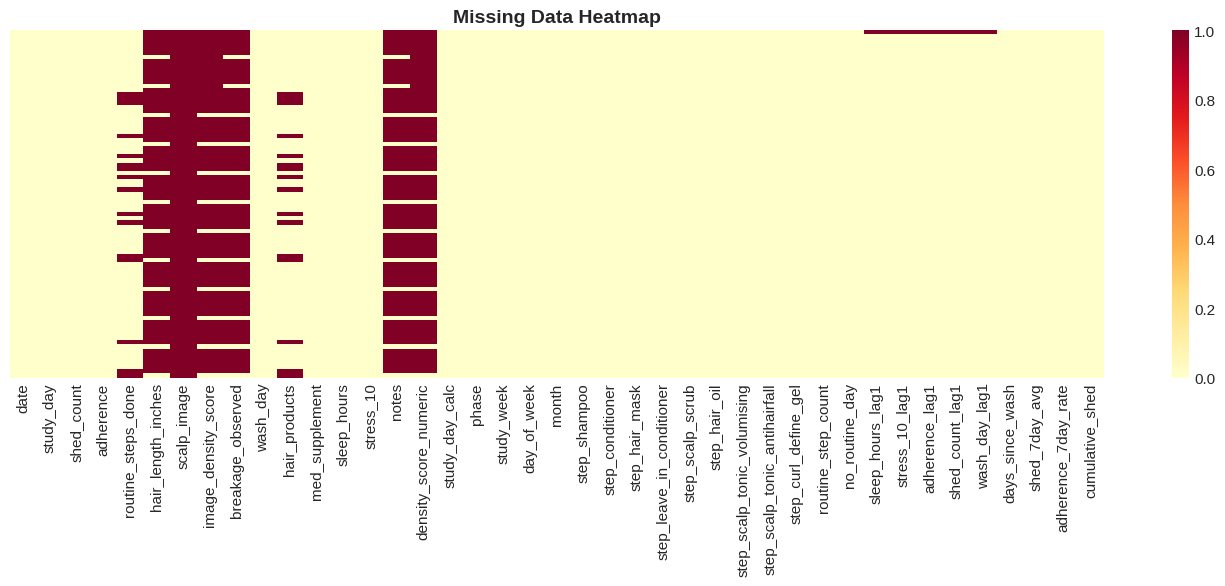

In [ ]:
# MISSING VALUES CHECK
print("\nMISSING VALUES:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing data
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
plt.title('Missing Data Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


OUTLIER DETECTION (Shed Count)
IQR Bounds: [-14.0, 42.0]
Outliers found: 7

Outlier details:


,date,shed_count,wash_day,phase,notes
0,2025-11-16,47,1,Baseline,NaN
6,2025-11-22,55,1,Baseline,177 total shed count
9,2025-11-25,44,1,Baseline,NaN
18,2025-12-05,52,1,Intervention,NaN
49,2026-01-05,45,1,Intervention,NaN
58,2026-01-14,57,1,Intervention,NaN
62,2026-01-18,47,1,Intervention,165 total shed count


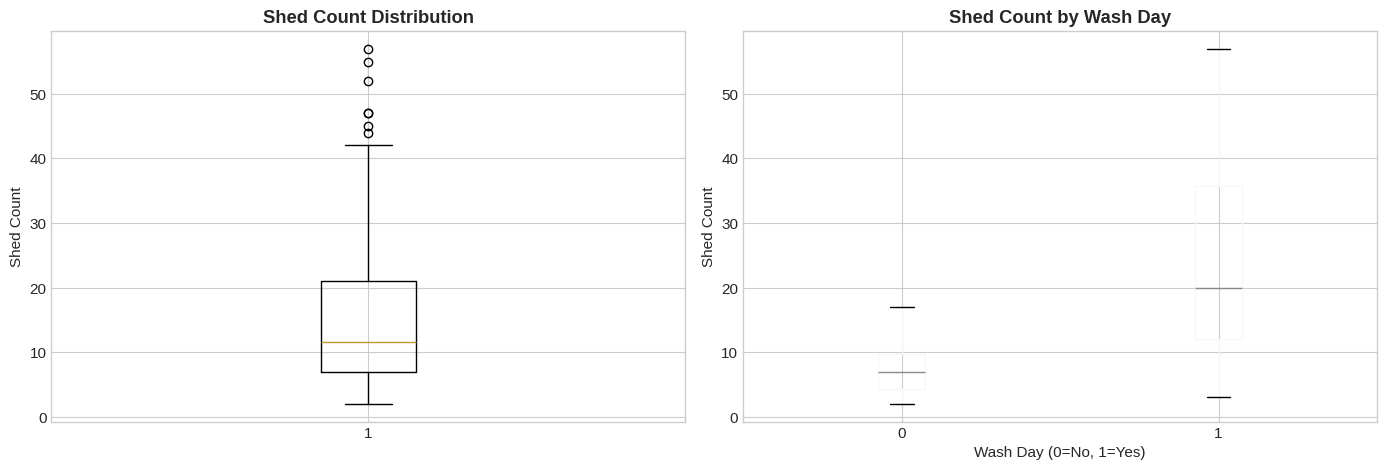


Note: Higher shed on wash days is expected - not true outliers


In [ ]:
# 5.3 OUTLIER DETECTION

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

# Check outliers in shed_count
shed_outliers, shed_lower, shed_upper = detect_outliers_iqr(df, 'shed_count')

print(f"\nOUTLIER DETECTION (Shed Count)")
print(f"IQR Bounds: [{shed_lower:.1f}, {shed_upper:.1f}]")
print(f"Outliers found: {len(shed_outliers)}")

if len(shed_outliers) > 0:
    print("\nOutlier details:")
    display(shed_outliers[['date', 'shed_count', 'wash_day', 'phase', 'notes']])

# Flag outliers (don't remove)
df['shed_outlier'] = ((df['shed_count'] < shed_lower) | (df['shed_count'] > shed_upper)).astype(int)

# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(df['shed_count'].dropna())
axes[0].set_title('Shed Count Distribution', fontweight='bold')
axes[0].set_ylabel('Shed Count')

# Box plot by wash day
df.boxplot(column='shed_count', by='wash_day', ax=axes[1])
axes[1].set_title('Shed Count by Wash Day', fontweight='bold')
axes[1].set_xlabel('Wash Day (0=No, 1=Yes)')
axes[1].set_ylabel('Shed Count')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("\nNote: Higher shed on wash days is expected - not true outliers")

Part 6: Research Questions Analysis

# RQ1: Overall Effectiveness
Does shed count decrease from baseline to intervention end?

RQ1: Does shed count decrease from baseline to intervention end?

Descriptive Statistics:
Phase                N      Mean       Median     Std       
--------------------------------------------------------
Baseline (W1-2)      14     22.21      15.50      16.87     
Intervention         70     15.47      11.00      13.15     
Last 14 days         14     11.93      11.00      7.70      

Normality Tests (Shapiro-Wilk):
Baseline: p = 0.0283 ✗ Non-normal
Intervention: p = 0.0000 ✗ Non-normal

Statistical Test: Mann-Whitney U test
Test statistic: 624.0000
p-value: 0.1087
   p-value (one-tailed, baseline > intervention): 0.0543

Effect Size (Cohen's d): 0.488
Interpretation: Small effect

Percent Change: -30.4%

CONCLUSION: No significant reduction detected (p ≥ 0.05)


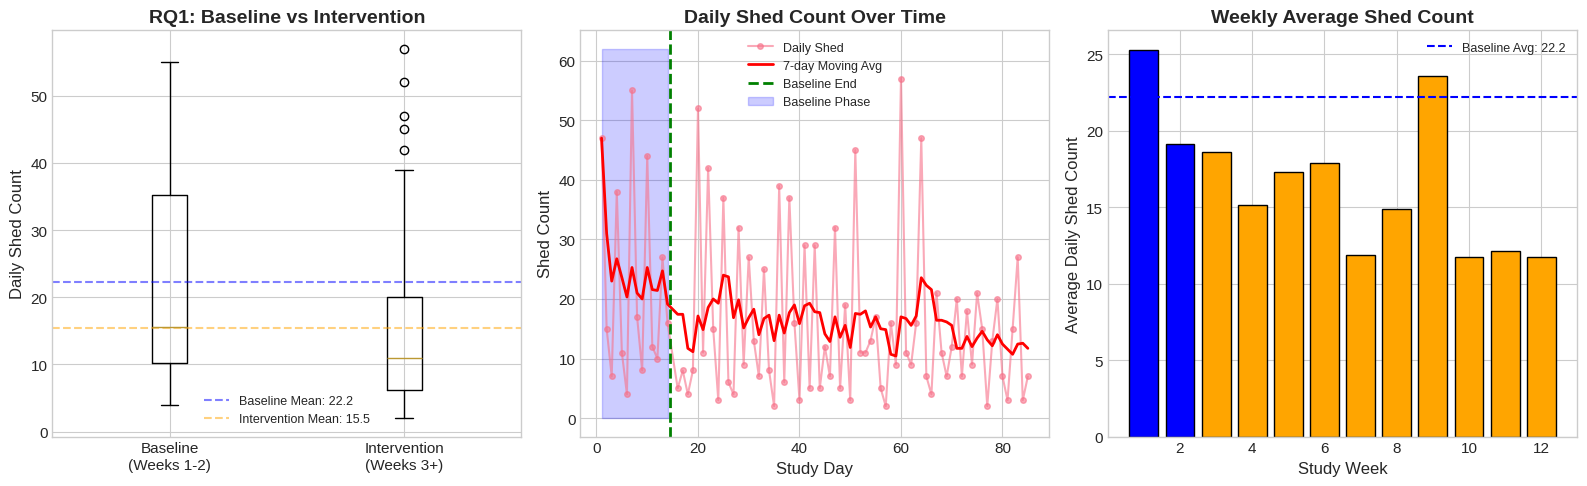


Figure saved: RQ1_baseline_vs_intervention.png


In [ ]:
# RQ1: BASELINE VS INTERVENTION COMPARISON

print("RQ1: Does shed count decrease from baseline to intervention end?")
print("=" * 70)

# Separate data by phase
baseline_shed = df[df['phase'] == 'Baseline']['shed_count'].dropna()
intervention_shed = df[df['phase'] == 'Intervention']['shed_count'].dropna()

# Also compare first 14 days vs last 14 days
last_14_days = df.tail(14)['shed_count'].dropna()

print(f"\nDescriptive Statistics:")
print(f"{'Phase':<20} {'N':<6} {'Mean':<10} {'Median':<10} {'Std':<10}")
print("-" * 56)
print(f"{'Baseline (W1-2)':<20} {len(baseline_shed):<6} {baseline_shed.mean():<10.2f} {baseline_shed.median():<10.2f} {baseline_shed.std():<10.2f}")
print(f"{'Intervention':<20} {len(intervention_shed):<6} {intervention_shed.mean():<10.2f} {intervention_shed.median():<10.2f} {intervention_shed.std():<10.2f}")
print(f"{'Last 14 days':<20} {len(last_14_days):<6} {last_14_days.mean():<10.2f} {last_14_days.median():<10.2f} {last_14_days.std():<10.2f}")

# Check normality
_, p_baseline = shapiro(baseline_shed)
_, p_intervention = shapiro(intervention_shed)

print(f"\nNormality Tests (Shapiro-Wilk):")
print(f"Baseline: p = {p_baseline:.4f} {'✓ Normal' if p_baseline > 0.05 else '✗ Non-normal'}")
print(f"Intervention: p = {p_intervention:.4f} {'✓ Normal' if p_intervention > 0.05 else '✗ Non-normal'}")

# Choose appropriate test
if p_baseline > 0.05 and p_intervention > 0.05:
    # Use t-test
    t_stat, p_value = ttest_ind(baseline_shed, intervention_shed)
    test_name = "Welch's t-test"
else:
    # Use Mann-Whitney U
    t_stat, p_value = mannwhitneyu(baseline_shed, intervention_shed, alternative='two-sided')
    test_name = "Mann-Whitney U test"

print(f"\nStatistical Test: {test_name}")
print(f"Test statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# One-tailed test (expecting decrease)
p_one_tailed = p_value / 2 if baseline_shed.mean() > intervention_shed.mean() else 1 - p_value/2
print(f"   p-value (one-tailed, baseline > intervention): {p_one_tailed:.4f}")

# Effect size (Cohen's d)
pooled_std = np.sqrt(((len(baseline_shed)-1)*baseline_shed.std()**2 +
                       (len(intervention_shed)-1)*intervention_shed.std()**2) /
                      (len(baseline_shed) + len(intervention_shed) - 2))
cohens_d = (baseline_shed.mean() - intervention_shed.mean()) / pooled_std

print(f"\nEffect Size (Cohen's d): {cohens_d:.3f}")
print(f"Interpretation: ", end="")
if abs(cohens_d) < 0.2:
    print("Negligible effect")
elif abs(cohens_d) < 0.5:
    print("Small effect")
elif abs(cohens_d) < 0.8:
    print("Medium effect")
else:
    print("Large effect")

# Percent change
pct_change = ((intervention_shed.mean() - baseline_shed.mean()) / baseline_shed.mean()) * 100
print(f"\nPercent Change: {pct_change:.1f}%")

# Significance conclusion
alpha = 0.05
if p_one_tailed < alpha:
    print(f"\nCONCLUSION: Significant reduction in shed count (p < {alpha})")
else:
    print(f"\nCONCLUSION: No significant reduction detected (p ≥ {alpha})")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Box plot comparison
axes[0].boxplot([baseline_shed, intervention_shed], labels=['Baseline\n(Weeks 1-2)', 'Intervention\n(Weeks 3+)'])
axes[0].set_ylabel('Daily Shed Count', fontsize=12)
axes[0].set_title('RQ1: Baseline vs Intervention', fontsize=14, fontweight='bold')
axes[0].axhline(y=baseline_shed.mean(), color='blue', linestyle='--', alpha=0.5, label=f'Baseline Mean: {baseline_shed.mean():.1f}')
axes[0].axhline(y=intervention_shed.mean(), color='orange', linestyle='--', alpha=0.5, label=f'Intervention Mean: {intervention_shed.mean():.1f}')
axes[0].legend(fontsize=9)

# Time series
axes[1].plot(df['study_day_calc'], df['shed_count'], 'o-', alpha=0.6, markersize=4, label='Daily Shed')
axes[1].plot(df['study_day_calc'], df['shed_7day_avg'], 'r-', linewidth=2, label='7-day Moving Avg')
axes[1].axvline(x=14.5, color='green', linestyle='--', linewidth=2, label='Baseline End')
axes[1].fill_between([1, 14], [0, 0], [df['shed_count'].max()+5]*2, alpha=0.2, color='blue', label='Baseline Phase')
axes[1].set_xlabel('Study Day', fontsize=12)
axes[1].set_ylabel('Shed Count', fontsize=12)
axes[1].set_title('Daily Shed Count Over Time', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)

# Weekly trend
weekly_shed = df.groupby('study_week')['shed_count'].mean()
axes[2].bar(weekly_shed.index, weekly_shed.values, color=['blue']*2 + ['orange']*(len(weekly_shed)-2), edgecolor='black')
axes[2].axhline(y=weekly_shed.iloc[:2].mean(), color='blue', linestyle='--', label=f'Baseline Avg: {weekly_shed.iloc[:2].mean():.1f}')
axes[2].set_xlabel('Study Week', fontsize=12)
axes[2].set_ylabel('Average Daily Shed Count', fontsize=12)
axes[2].set_title('Weekly Average Shed Count', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('RQ1_baseline_vs_intervention.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: RQ1_baseline_vs_intervention.png")

# RQ2: Routine Steps Correlation
Which routine steps correlate with reduced shedding?

RQ2: Which routine steps correlate with reduced shedding?
----------------------------------------------------------------------

Routine Step Correlations with Shed Count:
------------------------------------------------------------------------------------------
Step                      Correlation  p-value    Mean With    Mean Without Significant
------------------------------------------------------------------------------------------
leave_in_conditioner      -0.113       0.3046     11.8         17.1         
hair_mask                 -0.073       0.5082     15.3         17.4         
scalp_tonic_volumising    +0.016       0.8862     17.1         16.5         
hair_oil                  +0.406       0.0001     21.2         9.8          ✓
conditioner               +0.519       0.0000     26.0         11.1         ✓
shampoo                   +0.591       0.0000     23.9         7.4          ✓
scalp_tonic_antihairfall  +0.652       0.0000     38.8         12.9         ✓

Interpretatio

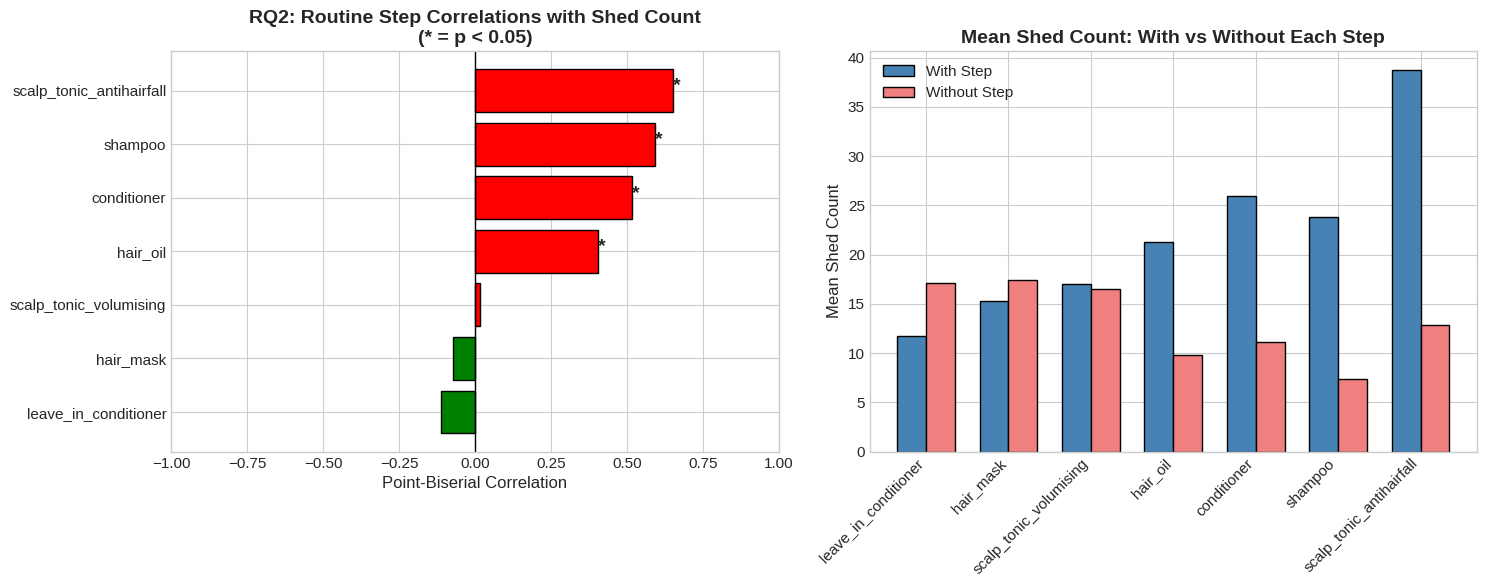


Figure saved: RQ2_routine_step_correlations.png


In [ ]:
# RQ2: ROUTINE STEPS CORRELATION WITH SHEDDING

print("RQ2: Which routine steps correlate with reduced shedding?")
print("-" * 70)

# Calculate point-biserial correlation for each step
step_correlations = {}

for step in routine_steps:
    col_name = f'step_{step}'
    if col_name in df.columns:
        # Only include days where we have shed count data
        valid_data = df[[col_name, 'shed_count']].dropna()

        if valid_data[col_name].nunique() > 1:  # Need variation
            corr, p_val = pointbiserialr(valid_data[col_name], valid_data['shed_count'])

            # Calculate means
            mean_with = df[df[col_name] == 1]['shed_count'].mean()
            mean_without = df[df[col_name] == 0]['shed_count'].mean()
            count_with = (df[col_name] == 1).sum()

            step_correlations[step] = {
                'correlation': corr,
                'p_value': p_val,
                'mean_with_step': mean_with,
                'mean_without_step': mean_without,
                'days_used': count_with,
                'significant': p_val < 0.05
            }

# Create results dataframe
corr_df = pd.DataFrame(step_correlations).T
corr_df = corr_df.sort_values('correlation')

print("\nRoutine Step Correlations with Shed Count:")
print("-" * 90)
print(f"{'Step':<25} {'Correlation':<12} {'p-value':<10} {'Mean With':<12} {'Mean Without':<12} {'Significant':<10}")
print("-" * 90)

for step, row in corr_df.iterrows():
    sig_marker = "✓" if row['significant'] else ""
    print(f"{step:<25} {row['correlation']:>+.3f}       {row['p_value']:<10.4f} {row['mean_with_step']:<12.1f} {row['mean_without_step']:<12.1f} {sig_marker}")

print("\nInterpretation:")
print("• Negative correlation = Step associated with LOWER shedding ✓")
print("• Positive correlation = Step associated with HIGHER shedding")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Correlation bar chart
colors = ['green' if x < 0 else 'red' for x in corr_df['correlation']]
bars = axes[0].barh(corr_df.index, corr_df['correlation'], color=colors, edgecolor='black')

# Add significance markers
for i, (step, row) in enumerate(corr_df.iterrows()):
    if row['significant']:
        axes[0].annotate('*', xy=(row['correlation'], i), fontsize=14, fontweight='bold',
                        ha='left' if row['correlation'] > 0 else 'right')

axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Point-Biserial Correlation', fontsize=12)
axes[0].set_title('RQ2: Routine Step Correlations with Shed Count\n(* = p < 0.05)', fontsize=14, fontweight='bold')
axes[0].set_xlim(-1, 1)

# Mean comparison chart
x = np.arange(len(corr_df))
width = 0.35

bars1 = axes[1].bar(x - width/2, corr_df['mean_with_step'], width, label='With Step', color='steelblue', edgecolor='black')
bars2 = axes[1].bar(x + width/2, corr_df['mean_without_step'], width, label='Without Step', color='lightcoral', edgecolor='black')

axes[1].set_ylabel('Mean Shed Count', fontsize=12)
axes[1].set_title('Mean Shed Count: With vs Without Each Step', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(corr_df.index, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('RQ2_routine_step_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: RQ2_routine_step_correlations.png")

# RQ3: Optimal Routine Combination
Is there an optimal combination of routine steps?


RQ3: Is there an optimal combination of routine steps?
----------------------------------------------------------------------

--- APPROACH 1: Multiple Regression ---

Regression Results:
R² = 0.6627
Adjusted R² = 0.6316
F-statistic p-value = 0.0000

Coefficients (sorted by effect):
                                Coefficient     Std Error   p-value
step_leave_in_conditioner     -2.621852e+00  6.795072e+00  0.700689
step_scalp_scrub              -1.107107e-14  8.437689e-15  0.193436
step_curl_define_gel           0.000000e+00  0.000000e+00       NaN
step_hair_mask                 1.385282e+00  4.307833e+00  0.748659
step_hair_oil                  1.684789e+00  2.972345e+00  0.572506
step_scalp_tonic_volumising    7.844957e+00  2.550457e+00  0.002916
step_conditioner               8.217606e+00  4.674461e+00  0.082777
step_shampoo                   9.629798e+00  3.857278e+00  0.014707
step_scalp_tonic_antihairfall  1.702373e+01  3.346847e+00  0.000003

--- APPROACH 2: Routine Profile Ana

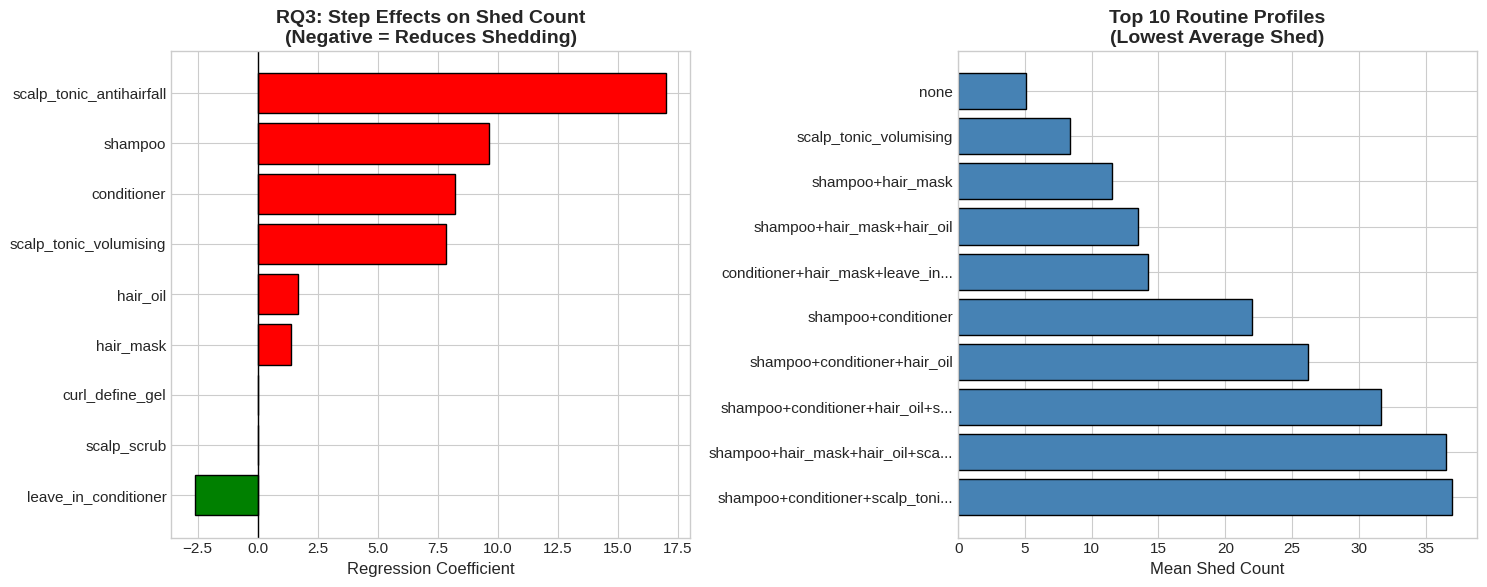


OPTIMAL ROUTINE (min 3 days data):
Steps: none
Average Shed: 5.1
Days Used: 16

Figure saved: RQ3_optimal_routine.png


In [ ]:
# RQ3: OPTIMAL ROUTINE COMBINATION

print("RQ3: Is there an optimal combination of routine steps?")
print("-" * 70)

# APPROACH 1: Multiple Regression
print("\n--- APPROACH 1: Multiple Regression ---")

# Prepare data for regression
regression_cols = [f'step_{step}' for step in routine_steps if f'step_{step}' in df.columns]
X = df[regression_cols].copy()
y = df['shed_count'].copy()

# Remove rows with missing values
valid_idx = ~(X.isna().any(axis=1) | y.isna())
X_valid = X[valid_idx]
y_valid = y[valid_idx]

# Add constant for intercept
X_const = sm.add_constant(X_valid)

# Fit model
model = sm.OLS(y_valid, X_const).fit()

print(f"\nRegression Results:")
print(f"R² = {model.rsquared:.4f}")
print(f"Adjusted R² = {model.rsquared_adj:.4f}")
print(f"F-statistic p-value = {model.f_pvalue:.4f}")

print(f"\nCoefficients (sorted by effect):")
coef_df = pd.DataFrame({
    'Coefficient': model.params,
    'Std Error': model.bse,
    'p-value': model.pvalues
}).drop('const', errors='ignore')

coef_df = coef_df.sort_values('Coefficient')
print(coef_df.to_string())

# APPROACH 2: Grouped Comparison by Routine Profile
print("\n--- APPROACH 2: Routine Profile Analysis ---")

# Create routine profile string
df['routine_profile'] = df[regression_cols].apply(
    lambda row: '+'.join([col.replace('step_', '') for col in regression_cols if row[col] == 1]) or 'none',
    axis=1
)

# Calculate mean shed by profile
profile_stats = df.groupby('routine_profile').agg({
    'shed_count': ['mean', 'std', 'count']
}).round(2)
profile_stats.columns = ['mean_shed', 'std_shed', 'days']
profile_stats = profile_stats.sort_values('mean_shed')

print("\nTop 10 Routine Profiles (Lowest Shed Count):")
print(profile_stats.head(10).to_string())

print("\nBottom 5 Routine Profiles (Highest Shed Count):")
print(profile_stats.tail(5).to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Coefficient plot
colors = ['green' if x < 0 else 'red' for x in coef_df['Coefficient']]
axes[0].barh(coef_df.index.str.replace('step_', ''), coef_df['Coefficient'],
             color=colors, edgecolor='black')
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_xlabel('Regression Coefficient', fontsize=12)
axes[0].set_title('RQ3: Step Effects on Shed Count\n(Negative = Reduces Shedding)', fontsize=14, fontweight='bold')

# Top profiles bar chart
top_profiles = profile_stats[profile_stats['days'] >= 2].head(10)
axes[1].barh(range(len(top_profiles)), top_profiles['mean_shed'], color='steelblue', edgecolor='black')
axes[1].set_yticks(range(len(top_profiles)))
axes[1].set_yticklabels([p[:30] + '...' if len(p) > 30 else p for p in top_profiles.index])
axes[1].set_xlabel('Mean Shed Count', fontsize=12)
axes[1].set_title('Top 10 Routine Profiles\n(Lowest Average Shed)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('RQ3_optimal_routine.png', dpi=150, bbox_inches='tight')
plt.show()

# Find optimal combination
if len(profile_stats[profile_stats['days'] >= 3]) > 0:
    optimal = profile_stats[profile_stats['days'] >= 3].iloc[0]
    optimal_name = profile_stats[profile_stats['days'] >= 3].index[0]
    print(f"\nOPTIMAL ROUTINE (min 3 days data):")
    print(f"Steps: {optimal_name}")
    print(f"Average Shed: {optimal['mean_shed']:.1f}")
    print(f"Days Used: {optimal['days']:.0f}")

print("\nFigure saved: RQ3_optimal_routine.png")

#RQ4-7: Lifestyle Factors
4. Is there a correlation between stress and shed count?
5. Does sleep duration affect next-day shedding?
6. Do stress and sleep together predict shed count better?
7. Which factor most strongly influences shedding?

In [ ]:
# RQ4: STRESS CORRELATION

print("RQ4: Is there a correlation between stress and shed count?")
print("-" * 70)

# Calculate correlation
stress_data = df[['stress_10', 'shed_count']].dropna()

# Check normality
_, p_stress = shapiro(stress_data['stress_10'])
_, p_shed = shapiro(stress_data['shed_count'])

print(f"\nNormality Tests:")
print(f"Stress: p = {p_stress:.4f}")
print(f"Shed Count: p = {p_shed:.4f}")

# Pearson and Spearman correlations
pearson_r, pearson_p = pearsonr(stress_data['stress_10'], stress_data['shed_count'])
spearman_r, spearman_p = spearmanr(stress_data['stress_10'], stress_data['shed_count'])

print(f"\nCorrelation Results:")
print(f"Pearson r = {pearson_r:.4f} (p = {pearson_p:.4f})")
print(f"Spearman ρ = {spearman_r:.4f} (p = {spearman_p:.4f})")

# Interpretation
def interpret_correlation(r):
    if abs(r) < 0.1:
        return "Negligible"
    elif abs(r) < 0.3:
        return "Weak"
    elif abs(r) < 0.5:
        return "Moderate"
    elif abs(r) < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"\nInterpretation: {interpret_correlation(pearson_r)} correlation")
if pearson_r > 0:
    print("Higher stress is associated with HIGHER shedding")
else:
    print("Higher stress is associated with LOWER shedding")

if pearson_p < 0.05:
    print(f"Statistically significant (p < 0.05)")
else:
    print(f"Not statistically significant (p ≥ 0.05)")

RQ4: Is there a correlation between stress and shed count?
----------------------------------------------------------------------

Normality Tests:
Stress: p = 0.0061
Shed Count: p = 0.0000

Correlation Results:
Pearson r = 0.2213 (p = 0.0430)
Spearman ρ = 0.2285 (p = 0.0365)

Interpretation: Weak correlation
Higher stress is associated with HIGHER shedding
Statistically significant (p < 0.05)


In [ ]:
# RQ5: SLEEP → NEXT-DAY SHEDDING

print("RQ5: Does sleep duration affect next-day shedding?")
print("-" * 70)

# Same-day correlation
same_day = df[['sleep_hours', 'shed_count']].dropna()
same_r, same_p = pearsonr(same_day['sleep_hours'], same_day['shed_count'])

# Lagged correlation (yesterday's sleep → today's shed)
lagged_data = df[['sleep_hours_lag1', 'shed_count']].dropna()
lag_r, lag_p = pearsonr(lagged_data['sleep_hours_lag1'], lagged_data['shed_count'])

print(f"\nCorrelation Results:")
print(f"Same-day (sleep vs shed): r = {same_r:.4f} (p = {same_p:.4f})")
print(f"Lagged (yesterday's sleep vs today's shed): r = {lag_r:.4f} (p = {lag_p:.4f})")

# Cross-correlation for multiple lags
print(f"\n📈 Cross-correlation at different lags:")
for lag in range(4):
    if lag == 0:
        lag_corr = df[['sleep_hours', 'shed_count']].dropna()
        r, p = pearsonr(lag_corr['sleep_hours'], lag_corr['shed_count'])
    else:
        df[f'sleep_lag{lag}'] = df['sleep_hours'].shift(lag)
        lag_corr = df[[f'sleep_lag{lag}', 'shed_count']].dropna()
        r, p = pearsonr(lag_corr[f'sleep_lag{lag}'], lag_corr['shed_count'])

    sig = "*" if p < 0.05 else ""
    print(f"   Lag {lag}: r = {r:+.4f} (p = {p:.4f}) {sig}")

print(f"\nInterpretation:")
if abs(lag_r) > abs(same_r):
    print("Sleep has DELAYED effect on shedding (next day)")
else:
    print("Sleep has IMMEDIATE effect on shedding (same day)")

RQ5: Does sleep duration affect next-day shedding?
----------------------------------------------------------------------

Correlation Results:
Same-day (sleep vs shed): r = 0.1740 (p = 0.1134)
Lagged (yesterday's sleep vs today's shed): r = -0.0501 (p = 0.6527)

📈 Cross-correlation at different lags:
   Lag 0: r = +0.1740 (p = 0.1134) 
   Lag 1: r = -0.0501 (p = 0.6527) 
   Lag 2: r = +0.1437 (p = 0.1977) 
   Lag 3: r = +0.0966 (p = 0.3911) 

Interpretation:
Sleep has IMMEDIATE effect on shedding (same day)


In [ ]:
# RQ6: COMBINED STRESS + SLEEP PREDICTION

print("RQ6: Do stress and sleep together predict shed count better?")
print("-" * 70)

# Prepare data
model_data = df[['shed_count', 'stress_10', 'sleep_hours']].dropna()

# Model 1: Stress only
X1 = sm.add_constant(model_data['stress_10'])
model1 = sm.OLS(model_data['shed_count'], X1).fit()

# Model 2: Sleep only
X2 = sm.add_constant(model_data['sleep_hours'])
model2 = sm.OLS(model_data['shed_count'], X2).fit()

# Model 3: Combined
X3 = sm.add_constant(model_data[['stress_10', 'sleep_hours']])
model3 = sm.OLS(model_data['shed_count'], X3).fit()

# Model 4: With interaction
model_data['stress_sleep_interaction'] = model_data['stress_10'] * model_data['sleep_hours']
X4 = sm.add_constant(model_data[['stress_10', 'sleep_hours', 'stress_sleep_interaction']])
model4 = sm.OLS(model_data['shed_count'], X4).fit()

print(f"\nModel Comparison:")
print(f"{'Model':<30} {'R²':<10} {'Adj R²':<10} {'AIC':<10} {'BIC':<10}")
print("-" * 70)
print(f"{'1. Stress only':<30} {model1.rsquared:<10.4f} {model1.rsquared_adj:<10.4f} {model1.aic:<10.2f} {model1.bic:<10.2f}")
print(f"{'2. Sleep only':<30} {model2.rsquared:<10.4f} {model2.rsquared_adj:<10.4f} {model2.aic:<10.2f} {model2.bic:<10.2f}")
print(f"{'3. Stress + Sleep':<30} {model3.rsquared:<10.4f} {model3.rsquared_adj:<10.4f} {model3.aic:<10.2f} {model3.bic:<10.2f}")
print(f"{'4. With Interaction':<30} {model4.rsquared:<10.4f} {model4.rsquared_adj:<10.4f} {model4.aic:<10.2f} {model4.bic:<10.2f}")

# Best model
models = {'Stress only': model1, 'Sleep only': model2, 'Combined': model3, 'With Interaction': model4}
best_model_name = min(models, key=lambda x: models[x].aic)
best_model = models[best_model_name]

print(f"\nBest Model (lowest AIC): {best_model_name}")

# Variance explained improvement
improvement = (model3.rsquared - max(model1.rsquared, model2.rsquared)) * 100
print(f"\nR² Improvement from combining: {improvement:.2f}%")

if model3.rsquared > max(model1.rsquared, model2.rsquared):
    print("Combined model explains MORE variance than individual models")
else:
    print("Combined model does NOT improve over individual models")

RQ6: Do stress and sleep together predict shed count better?
----------------------------------------------------------------------

Model Comparison:
Model                          R²         Adj R²     AIC        BIC       
----------------------------------------------------------------------
1. Stress only                 0.0490     0.0374     679.94     684.80    
2. Sleep only                  0.0303     0.0185     681.58     686.44    
3. Stress + Sleep              0.0811     0.0584     679.05     686.35    
4. With Interaction            0.0817     0.0472     681.00     690.73    

Best Model (lowest AIC): Combined

R² Improvement from combining: 3.21%
Combined model explains MORE variance than individual models


RQ7: Which factor most strongly influences shedding?
----------------------------------------------------------------------

Standardized Regression Coefficients:
   (Larger absolute value = stronger influence)
--------------------------------------------------
   1. Adherence    β = +4.238 (p = 0.0046) ↑ increases shed ✓
   2. Stress       β = +3.087 (p = 0.0319) ↑ increases shed ✓
   3. Sleep        β = +1.495 (p = 0.3070) ↑ increases shed 

STRONGEST FACTOR: Adherence


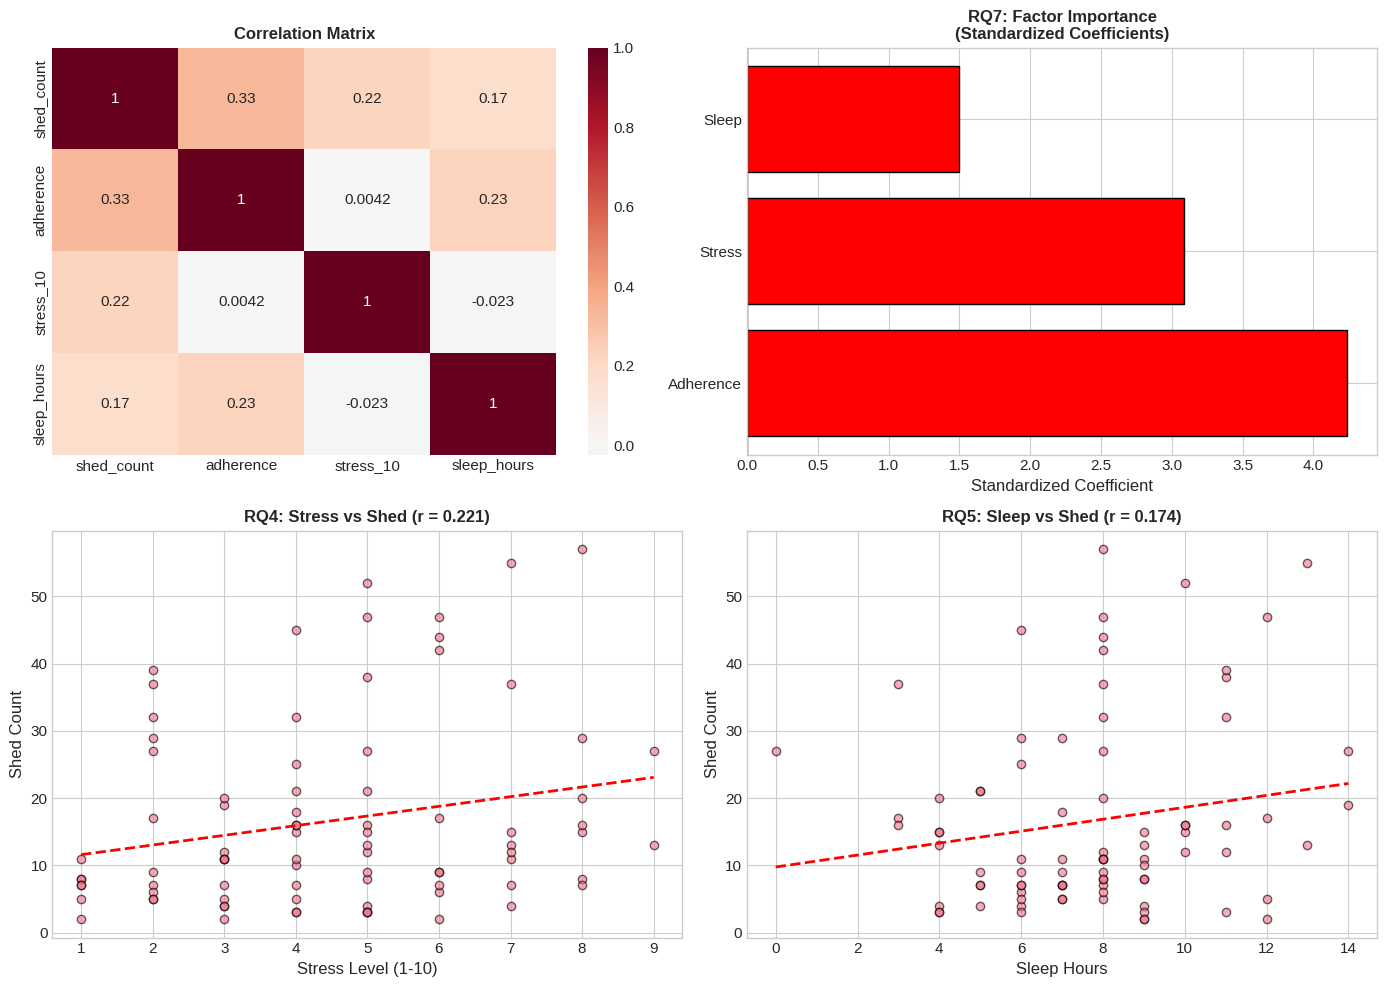


Figure saved: RQ4-7_lifestyle_factors.png


In [ ]:
# RQ7: STRONGEST FACTOR IDENTIFICATION

print("RQ7: Which factor most strongly influences shedding?")
print("-" * 70)

# Prepare data with all predictors
factor_data = df[['shed_count', 'adherence', 'stress_10', 'sleep_hours']].dropna()

# Standardize predictors for fair comparison
from scipy.stats import zscore

factor_data_std = factor_data.copy()
for col in ['adherence', 'stress_10', 'sleep_hours']:
    factor_data_std[f'{col}_z'] = zscore(factor_data_std[col])

# Fit standardized regression
X_std = sm.add_constant(factor_data_std[['adherence_z', 'stress_10_z', 'sleep_hours_z']])
model_std = sm.OLS(factor_data_std['shed_count'], X_std).fit()

print(f"\nStandardized Regression Coefficients:")
print(f"   (Larger absolute value = stronger influence)")
print("-" * 50)

coef_importance = pd.DataFrame({
    'Factor': ['Adherence', 'Stress', 'Sleep'],
    'Std_Coefficient': [model_std.params['adherence_z'],
                       model_std.params['stress_10_z'],
                       model_std.params['sleep_hours_z']],
    'p-value': [model_std.pvalues['adherence_z'],
               model_std.pvalues['stress_10_z'],
               model_std.pvalues['sleep_hours_z']]
})

coef_importance['Abs_Coefficient'] = coef_importance['Std_Coefficient'].abs()
coef_importance = coef_importance.sort_values('Abs_Coefficient', ascending=False)
coef_importance['Rank'] = range(1, len(coef_importance) + 1)

for _, row in coef_importance.iterrows():
    sig = "✓" if row['p-value'] < 0.05 else ""
    direction = "↑ increases shed" if row['Std_Coefficient'] > 0 else "↓ decreases shed"
    print(f"   {row['Rank']}. {row['Factor']:<12} β = {row['Std_Coefficient']:+.3f} (p = {row['p-value']:.4f}) {direction} {sig}")

strongest = coef_importance.iloc[0]['Factor']
print(f"\nSTRONGEST FACTOR: {strongest}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Correlation heatmap
corr_matrix = factor_data[['shed_count', 'adherence', 'stress_10', 'sleep_hours']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Correlation Matrix', fontsize=12, fontweight='bold')

# Standardized coefficients
colors = ['green' if x < 0 else 'red' for x in coef_importance['Std_Coefficient']]
axes[0, 1].barh(coef_importance['Factor'], coef_importance['Std_Coefficient'], color=colors, edgecolor='black')
axes[0, 1].axvline(x=0, color='black', linewidth=1)
axes[0, 1].set_xlabel('Standardized Coefficient', fontsize=12)
axes[0, 1].set_title('RQ7: Factor Importance\n(Standardized Coefficients)', fontsize=12, fontweight='bold')

# Stress vs Shed scatter
axes[1, 0].scatter(df['stress_10'], df['shed_count'], alpha=0.6, edgecolor='black')
z = np.polyfit(df['stress_10'].dropna(), df.loc[df['stress_10'].notna(), 'shed_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['stress_10'].min(), df['stress_10'].max(), 100)
axes[1, 0].plot(x_line, p(x_line), 'r--', linewidth=2)
axes[1, 0].set_xlabel('Stress Level (1-10)', fontsize=12)
axes[1, 0].set_ylabel('Shed Count', fontsize=12)
axes[1, 0].set_title(f'RQ4: Stress vs Shed (r = {pearson_r:.3f})', fontsize=12, fontweight='bold')

# Sleep vs Shed scatter
axes[1, 1].scatter(df['sleep_hours'], df['shed_count'], alpha=0.6, edgecolor='black')
z = np.polyfit(df['sleep_hours'].dropna(), df.loc[df['sleep_hours'].notna(), 'shed_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['sleep_hours'].min(), df['sleep_hours'].max(), 100)
axes[1, 1].plot(x_line, p(x_line), 'r--', linewidth=2)
axes[1, 1].set_xlabel('Sleep Hours', fontsize=12)
axes[1, 1].set_ylabel('Shed Count', fontsize=12)
axes[1, 1].set_title(f'RQ5: Sleep vs Shed (r = {same_r:.3f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('RQ4-7_lifestyle_factors.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: RQ4-7_lifestyle_factors.png")

#RQ8-9: Adherence Effects
8. Does higher adherence correlate with lower shed counts?
9. Does non-adherence lead to increased shedding next day?

In [ ]:
# RQ8: ADHERENCE CORRELATION

print("RQ8: Does higher adherence correlate with lower shed counts?")
print("-" * 70)

# Point-biserial correlation
adherence_data = df[['adherence', 'shed_count']].dropna()
adh_r, adh_p = pointbiserialr(adherence_data['adherence'], adherence_data['shed_count'])

print(f"\nPoint-Biserial Correlation:")
print(f"r = {adh_r:.4f} (p = {adh_p:.4f})")

# Group comparison
adherent_shed = df[df['adherence'] == 1]['shed_count'].dropna()
non_adherent_shed = df[df['adherence'] == 0]['shed_count'].dropna()

print(f"\nGroup Comparison:")
print(f"Adherent days (n={len(adherent_shed)}): Mean = {adherent_shed.mean():.2f}, Median = {adherent_shed.median():.1f}")
print(f"Non-adherent days (n={len(non_adherent_shed)}): Mean = {non_adherent_shed.mean():.2f}, Median = {non_adherent_shed.median():.1f}")

# Statistical test
if len(adherent_shed) > 0 and len(non_adherent_shed) > 0:
    t_stat, p_val = ttest_ind(adherent_shed, non_adherent_shed)
    print(f"\nIndependent t-test:")
    print(f"t = {t_stat:.4f}, p = {p_val:.4f}")

    if p_val < 0.05:
        print(f"Significant difference between adherent and non-adherent days")
    else:
        print(f"No significant difference detected")

# Effect size
if len(adherent_shed) > 0 and len(non_adherent_shed) > 0:
    pooled_std = np.sqrt(((len(adherent_shed)-1)*adherent_shed.std()**2 +
                           (len(non_adherent_shed)-1)*non_adherent_shed.std()**2) /
                          (len(adherent_shed) + len(non_adherent_shed) - 2))
    cohens_d_adh = (non_adherent_shed.mean() - adherent_shed.mean()) / pooled_std if pooled_std > 0 else 0
    print(f"   Effect size (Cohen's d): {cohens_d_adh:.3f}")

RQ8: Does higher adherence correlate with lower shed counts?
----------------------------------------------------------------------

Point-Biserial Correlation:
r = 0.3317 (p = 0.0021)

Group Comparison:
Adherent days (n=30): Mean = 22.77, Median = 16.5
Non-adherent days (n=54): Mean = 13.17, Median = 9.0

Independent t-test:
t = 3.1837, p = 0.0021
Significant difference between adherent and non-adherent days
   Effect size (Cohen's d): -0.725


RQ9: Does non-adherence lead to increased shedding next day?
----------------------------------------------------------------------

Next-Day Shed Count Comparison:
After adherent day (n=30): Mean = 15.60
After non-adherent day (n=53): Mean = 16.58
Difference: +0.98 hairs

Independent t-test:
t = 0.3147, p = 0.7538
No significant next-day effect detected


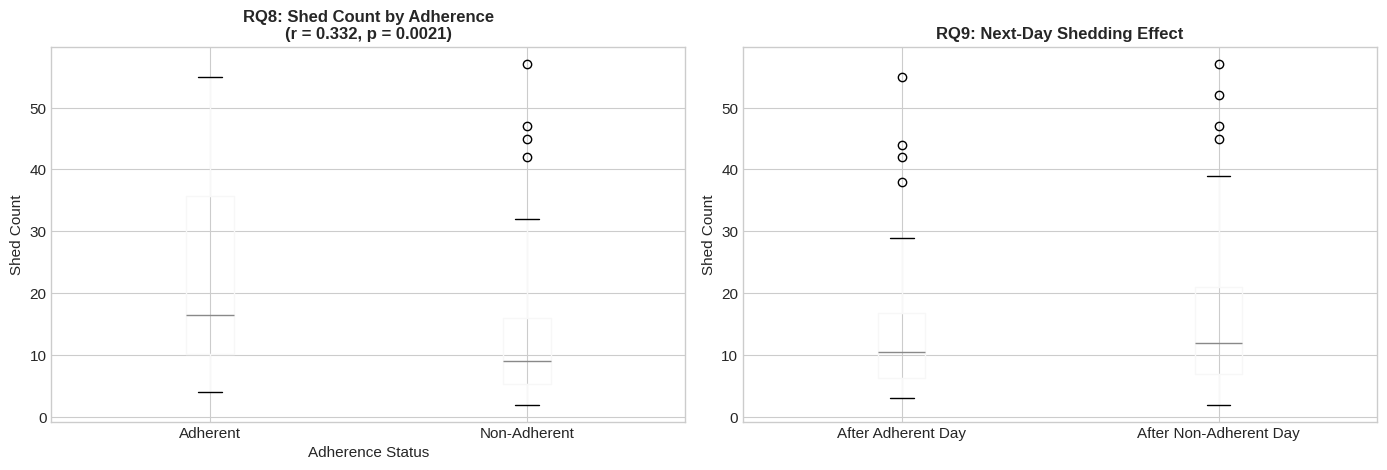


Figure saved: RQ8-9_adherence_effects.png


In [ ]:
# RQ9: NON-ADHERENCE → NEXT-DAY SHEDDING

print("RQ9: Does non-adherence lead to increased shedding next day?")
print("-" * 70)

# Create lagged adherence comparison
df['prev_day_adherent'] = df['adherence_lag1'].map({1: 'After Adherent Day', 0: 'After Non-Adherent Day'})

# Compare shed counts
after_adherent = df[df['adherence_lag1'] == 1]['shed_count'].dropna()
after_non_adherent = df[df['adherence_lag1'] == 0]['shed_count'].dropna()

print(f"\nNext-Day Shed Count Comparison:")
print(f"After adherent day (n={len(after_adherent)}): Mean = {after_adherent.mean():.2f}")
print(f"After non-adherent day (n={len(after_non_adherent)}): Mean = {after_non_adherent.mean():.2f}")

if len(after_adherent) > 0 and len(after_non_adherent) > 0:
    difference = after_non_adherent.mean() - after_adherent.mean()
    print(f"Difference: {difference:+.2f} hairs")

    # Statistical test
    t_stat, p_val = ttest_ind(after_non_adherent, after_adherent)
    print(f"\nIndependent t-test:")
    print(f"t = {t_stat:.4f}, p = {p_val:.4f}")

    if p_val < 0.05 and difference > 0:
        print(f"Non-adherence significantly INCREASES next-day shedding")
    elif p_val < 0.05 and difference < 0:
        print(f"Non-adherence significantly DECREASES next-day shedding (unexpected)")
    else:
        print(f"No significant next-day effect detected")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RQ8: Adherence box plot
df_plot = df.copy()
df_plot['adherence_label'] = df_plot['adherence'].map({1: 'Adherent', 0: 'Non-Adherent'})
df_plot.boxplot(column='shed_count', by='adherence_label', ax=axes[0])
axes[0].set_title(f'RQ8: Shed Count by Adherence\n(r = {adh_r:.3f}, p = {adh_p:.4f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Adherence Status')
axes[0].set_ylabel('Shed Count')
plt.suptitle('')

# RQ9: Next-day effect
if 'prev_day_adherent' in df.columns:
    df_next = df[df['prev_day_adherent'].notna()]
    df_next.boxplot(column='shed_count', by='prev_day_adherent', ax=axes[1])
    axes[1].set_title(f'RQ9: Next-Day Shedding Effect', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Shed Count')
    plt.suptitle('')

plt.tight_layout()
plt.savefig('RQ8-9_adherence_effects.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: RQ8-9_adherence_effects.png")

# RQ10: Density vs Shed Relationship
Is there a relationship between density improvement and shed reduction?


RQ10: Is there a relationship between density improvement and shed reduction?
----------------------------------------------------------------------

Weekly Data Available: 10 weeks with both metrics

Correlation: Density Score vs Weekly Avg Shed
r = -0.4190 (p = 0.2281)

Interpretation:
Higher density is associated with LOWER shedding ✓

Trend Analysis:
Density trend: +1.41 points/week
Shed count trend: -0.55 hairs/week
POSITIVE OUTCOME: Density increasing while shedding decreasing


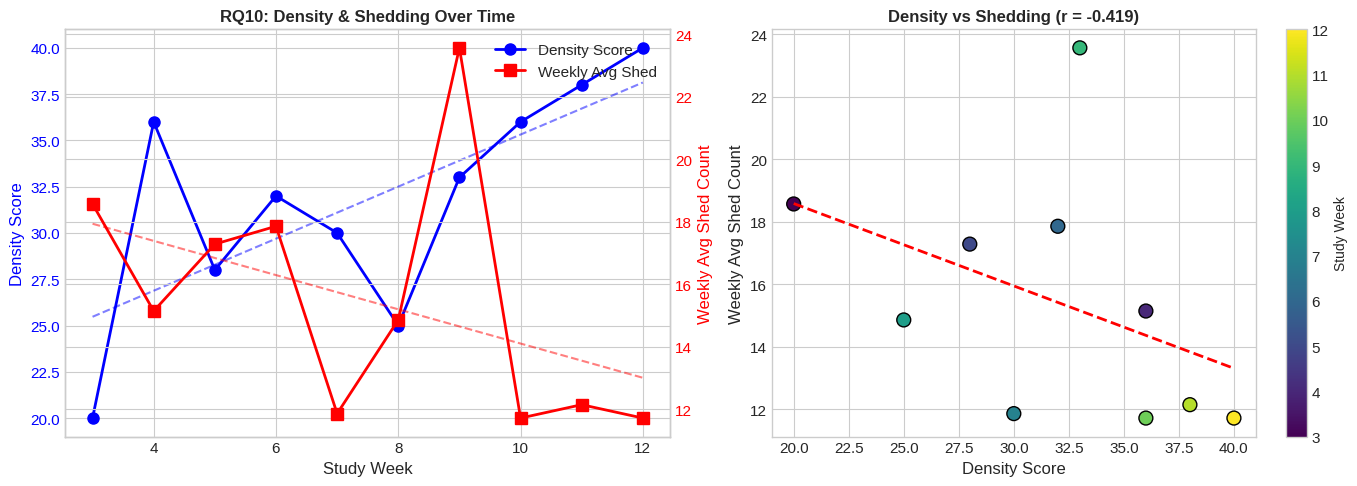


Figure saved: RQ10_density_vs_shedding.png


In [ ]:
# RQ10: DENSITY SCORE VS SHED COUNT RELATIONSHIP

print("RQ10: Is there a relationship between density improvement and shed reduction?")
print("-" * 70)

# Work with weekly data
weekly_analysis = weekly_df[['study_week', 'weekly_avg_shed', 'weekly_total_shed', 'density_score']].dropna()

print(f"\nWeekly Data Available: {len(weekly_analysis)} weeks with both metrics")

if len(weekly_analysis) >= 3:
    # Correlation
    density_shed_r, density_shed_p = pearsonr(weekly_analysis['density_score'],
                                               weekly_analysis['weekly_avg_shed'])

    print(f"\nCorrelation: Density Score vs Weekly Avg Shed")
    print(f"r = {density_shed_r:.4f} (p = {density_shed_p:.4f})")

    print(f"\nInterpretation:")
    if density_shed_r < 0:
        print("Higher density is associated with LOWER shedding ✓")
    else:
        print("Higher density is associated with HIGHER shedding")

    # Trend analysis
    print(f"\nTrend Analysis:")

    # Density trend
    density_trend = np.polyfit(weekly_analysis['study_week'], weekly_analysis['density_score'], 1)
    print(f"Density trend: {density_trend[0]:+.2f} points/week")

    # Shed trend
    shed_trend = np.polyfit(weekly_analysis['study_week'], weekly_analysis['weekly_avg_shed'], 1)
    print(f"Shed count trend: {shed_trend[0]:+.2f} hairs/week")

    if density_trend[0] > 0 and shed_trend[0] < 0:
        print("POSITIVE OUTCOME: Density increasing while shedding decreasing")
    elif density_trend[0] > 0:
        print("Density improving but shedding not clearly decreasing")
    else:
        print("Trends need further investigation")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Dual axis time series
    ax1 = axes[0]
    ax2 = ax1.twinx()

    line1 = ax1.plot(weekly_analysis['study_week'], weekly_analysis['density_score'],
                     'b-o', linewidth=2, markersize=8, label='Density Score')
    ax1.set_xlabel('Study Week', fontsize=12)
    ax1.set_ylabel('Density Score', color='blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='blue')

    line2 = ax2.plot(weekly_analysis['study_week'], weekly_analysis['weekly_avg_shed'],
                     'r-s', linewidth=2, markersize=8, label='Weekly Avg Shed')
    ax2.set_ylabel('Weekly Avg Shed Count', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')

    # Add trend lines
    x_trend = np.linspace(weekly_analysis['study_week'].min(), weekly_analysis['study_week'].max(), 100)
    ax1.plot(x_trend, np.polyval(density_trend, x_trend), 'b--', alpha=0.5)
    ax2.plot(x_trend, np.polyval(shed_trend, x_trend), 'r--', alpha=0.5)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')
    ax1.set_title('RQ10: Density & Shedding Over Time', fontsize=12, fontweight='bold')

    # Scatter plot
    axes[1].scatter(weekly_analysis['density_score'], weekly_analysis['weekly_avg_shed'],
                    s=100, c=weekly_analysis['study_week'], cmap='viridis', edgecolor='black')

    # Add regression line
    z = np.polyfit(weekly_analysis['density_score'], weekly_analysis['weekly_avg_shed'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(weekly_analysis['density_score'].min(), weekly_analysis['density_score'].max(), 100)
    axes[1].plot(x_line, p(x_line), 'r--', linewidth=2)

    axes[1].set_xlabel('Density Score', fontsize=12)
    axes[1].set_ylabel('Weekly Avg Shed Count', fontsize=12)
    axes[1].set_title(f'Density vs Shedding (r = {density_shed_r:.3f})', fontsize=12, fontweight='bold')

    # Add colorbar for week
    cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
    cbar.set_label('Study Week', fontsize=10)

    plt.tight_layout()
    plt.savefig('RQ10_density_vs_shedding.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nFigure saved: RQ10_density_vs_shedding.png")

else:
    print("Insufficient weekly data with both density and shed measurements")
    print("Need at least 3 weeks of paired data for meaningful correlation")


In [ ]:
# PART 7: COMPREHENSIVE RESULTS SUMMARY

print("COMPREHENSIVE RESULTS SUMMARY")
print("-" * 70)

# Create summary dataframe
results_summary = []

# RQ1: Overall Effectiveness
results_summary.append({
    'Research Question': 'RQ1: Overall Effectiveness',
    'Finding': f"Baseline mean: {baseline_shed.mean():.1f} → Intervention mean: {intervention_shed.mean():.1f}",
    'Change': f"{pct_change:+.1f}%",
    'Statistical Test': test_name,
    'p-value': f"{p_one_tailed:.4f}",
    'Significant': '✓' if p_one_tailed < 0.05 else '✗',
    'Effect Size': f"d = {cohens_d:.3f}"
})

# RQ2: Routine Steps
best_step = corr_df[corr_df['correlation'] == corr_df['correlation'].min()].index[0] if len(corr_df) > 0 else 'N/A'
worst_step = corr_df[corr_df['correlation'] == corr_df['correlation'].max()].index[0] if len(corr_df) > 0 else 'N/A'
results_summary.append({
    'Research Question': 'RQ2: Best Routine Steps',
    'Finding': f"Best: {best_step} | Worst: {worst_step}",
    'Change': 'N/A',
    'Statistical Test': 'Point-biserial correlation',
    'p-value': 'See detailed results',
    'Significant': 'Varies',
    'Effect Size': 'See correlations'
})

# RQ3: Optimal Combination
results_summary.append({
    'Research Question': 'RQ3: Optimal Combination',
    'Finding': f"Best profile: {optimal_name if 'optimal_name' in dir() else 'See analysis'}",
    'Change': 'N/A',
    'Statistical Test': 'Multiple regression',
    'p-value': f"{model.f_pvalue:.4f}" if 'model' in dir() else 'N/A',
    'Significant': '✓' if 'model' in dir() and model.f_pvalue < 0.05 else '✗',
    'Effect Size': f"R² = {model.rsquared:.3f}" if 'model' in dir() else 'N/A'
})

# RQ4: Stress
results_summary.append({
    'Research Question': 'RQ4: Stress Correlation',
    'Finding': f"r = {pearson_r:+.3f} ({interpret_correlation(pearson_r)})",
    'Change': 'Higher stress → Higher shed' if pearson_r > 0 else 'Higher stress → Lower shed',
    'Statistical Test': 'Pearson correlation',
    'p-value': f"{pearson_p:.4f}",
    'Significant': '✓' if pearson_p < 0.05 else '✗',
    'Effect Size': f"r = {pearson_r:.3f}"
})

# RQ5: Sleep (lagged)
results_summary.append({
    'Research Question': 'RQ5: Sleep → Next-Day Shed',
    'Finding': f"Lagged r = {lag_r:+.3f}",
    'Change': 'More sleep → Less shed' if lag_r < 0 else 'More sleep → More shed',
    'Statistical Test': 'Lagged Pearson correlation',
    'p-value': f"{lag_p:.4f}",
    'Significant': '✓' if lag_p < 0.05 else '✗',
    'Effect Size': f"r = {lag_r:.3f}"
})

# RQ6: Combined Model
results_summary.append({
    'Research Question': 'RQ6: Combined Stress+Sleep',
    'Finding': f"Best model: {best_model_name}",
    'Change': f"R² improvement: {improvement:+.2f}%",
    'Statistical Test': 'Multiple regression comparison',
    'p-value': 'See model comparison',
    'Significant': '✓' if improvement > 0 else '✗',
    'Effect Size': f"R² = {model3.rsquared:.3f}"
})

# RQ7: Strongest Factor
results_summary.append({
    'Research Question': 'RQ7: Strongest Factor',
    'Finding': f"Strongest: {strongest}",
    'Change': 'See standardized coefficients',
    'Statistical Test': 'Standardized regression',
    'p-value': 'See detailed results',
    'Significant': 'Varies',
    'Effect Size': 'See β values'
})

# RQ8: Adherence
results_summary.append({
    'Research Question': 'RQ8: Adherence Correlation',
    'Finding': f"r = {adh_r:+.3f}",
    'Change': f"Adherent: {adherent_shed.mean():.1f} vs Non: {non_adherent_shed.mean():.1f}",
    'Statistical Test': 'Point-biserial correlation',
    'p-value': f"{adh_p:.4f}",
    'Significant': '✓' if adh_p < 0.05 else '✗',
    'Effect Size': f"r = {adh_r:.3f}"
})

# RQ9: Non-adherence next day
if len(after_adherent) > 0 and len(after_non_adherent) > 0:
    results_summary.append({
        'Research Question': 'RQ9: Non-Adherence Next-Day',
        'Finding': f"After non-adherent: {after_non_adherent.mean():.1f} vs After adherent: {after_adherent.mean():.1f}",
        'Change': f"{after_non_adherent.mean() - after_adherent.mean():+.1f} hairs",
        'Statistical Test': 'Independent t-test',
        'p-value': f"{p_val:.4f}",
        'Significant': '✓' if p_val < 0.05 else '✗',
        'Effect Size': 'See comparison'
    })

# RQ10: Density relationship
if len(weekly_analysis) >= 3:
    results_summary.append({
        'Research Question': 'RQ10: Density vs Shedding',
        'Finding': f"r = {density_shed_r:+.3f}",
        'Change': f"Density trend: {density_trend[0]:+.2f}/week | Shed trend: {shed_trend[0]:+.2f}/week",
        'Statistical Test': 'Pearson correlation',
        'p-value': f"{density_shed_p:.4f}",
        'Significant': '✓' if density_shed_p < 0.05 else '✗',
        'Effect Size': f"r = {density_shed_r:.3f}"
    })

# Create and display summary table
summary_df = pd.DataFrame(results_summary)
print("\nRESULTS SUMMARY TABLE:")
print("=" * 120)
display(summary_df)

# Save to CSV
summary_df.to_csv('research_questions_summary.csv', index=False)
print("\nSummary saved to: research_questions_summary.csv")

COMPREHENSIVE RESULTS SUMMARY
----------------------------------------------------------------------

RESULTS SUMMARY TABLE:


,Research Question,Finding,Change,Statistical Test,p-value,Significant,Effect Size
0,RQ1: Overall Effectiveness,Baseline mean: 22.2 → Intervention mean: 15.5,-30.4%,Mann-Whitney U test,0.0543,✗,d = 0.488
1,RQ2: Best Routine Steps,Best: leave_in_conditioner | Worst: scalp_toni...,N/A,Point-biserial correlation,See detailed results,Varies,See correlations
2,RQ3: Optimal Combination,Best profile: none,N/A,Multiple regression,0.0000,✓,R² = 0.663
3,RQ4: Stress Correlation,r = +0.221 (Weak),Higher stress → Higher shed,Pearson correlation,0.0430,✓,r = 0.221
4,RQ5: Sleep → Next-Day Shed,Lagged r = -0.050,More sleep → Less shed,Lagged Pearson correlation,0.6527,✗,r = -0.050
5,RQ6: Combined Stress+Sleep,Best model: Combined,R² improvement: +3.21%,Multiple regression comparison,See model comparison,✓,R² = 0.081
6,RQ7: Strongest Factor,Strongest: Adherence,See standardized coefficients,Standardized regression,See detailed results,Varies,See β values
7,RQ8: Adherence Correlation,r = +0.332,Adherent: 22.8 vs Non: 13.2,Point-biserial correlation,0.0021,✓,r = 0.332
8,RQ9: Non-Adherence Next-Day,After non-adherent: 16.6 vs After adherent: 15.6,+1.0 hairs,Independent t-test,0.7538,✗,See comparison
9,RQ10: Density vs Shedding,r = -0.419,Density trend: +1.41/week | Shed trend: -0.55/...,Pearson correlation,0.2281,✗,r = -0.419



Summary saved to: research_questions_summary.csv


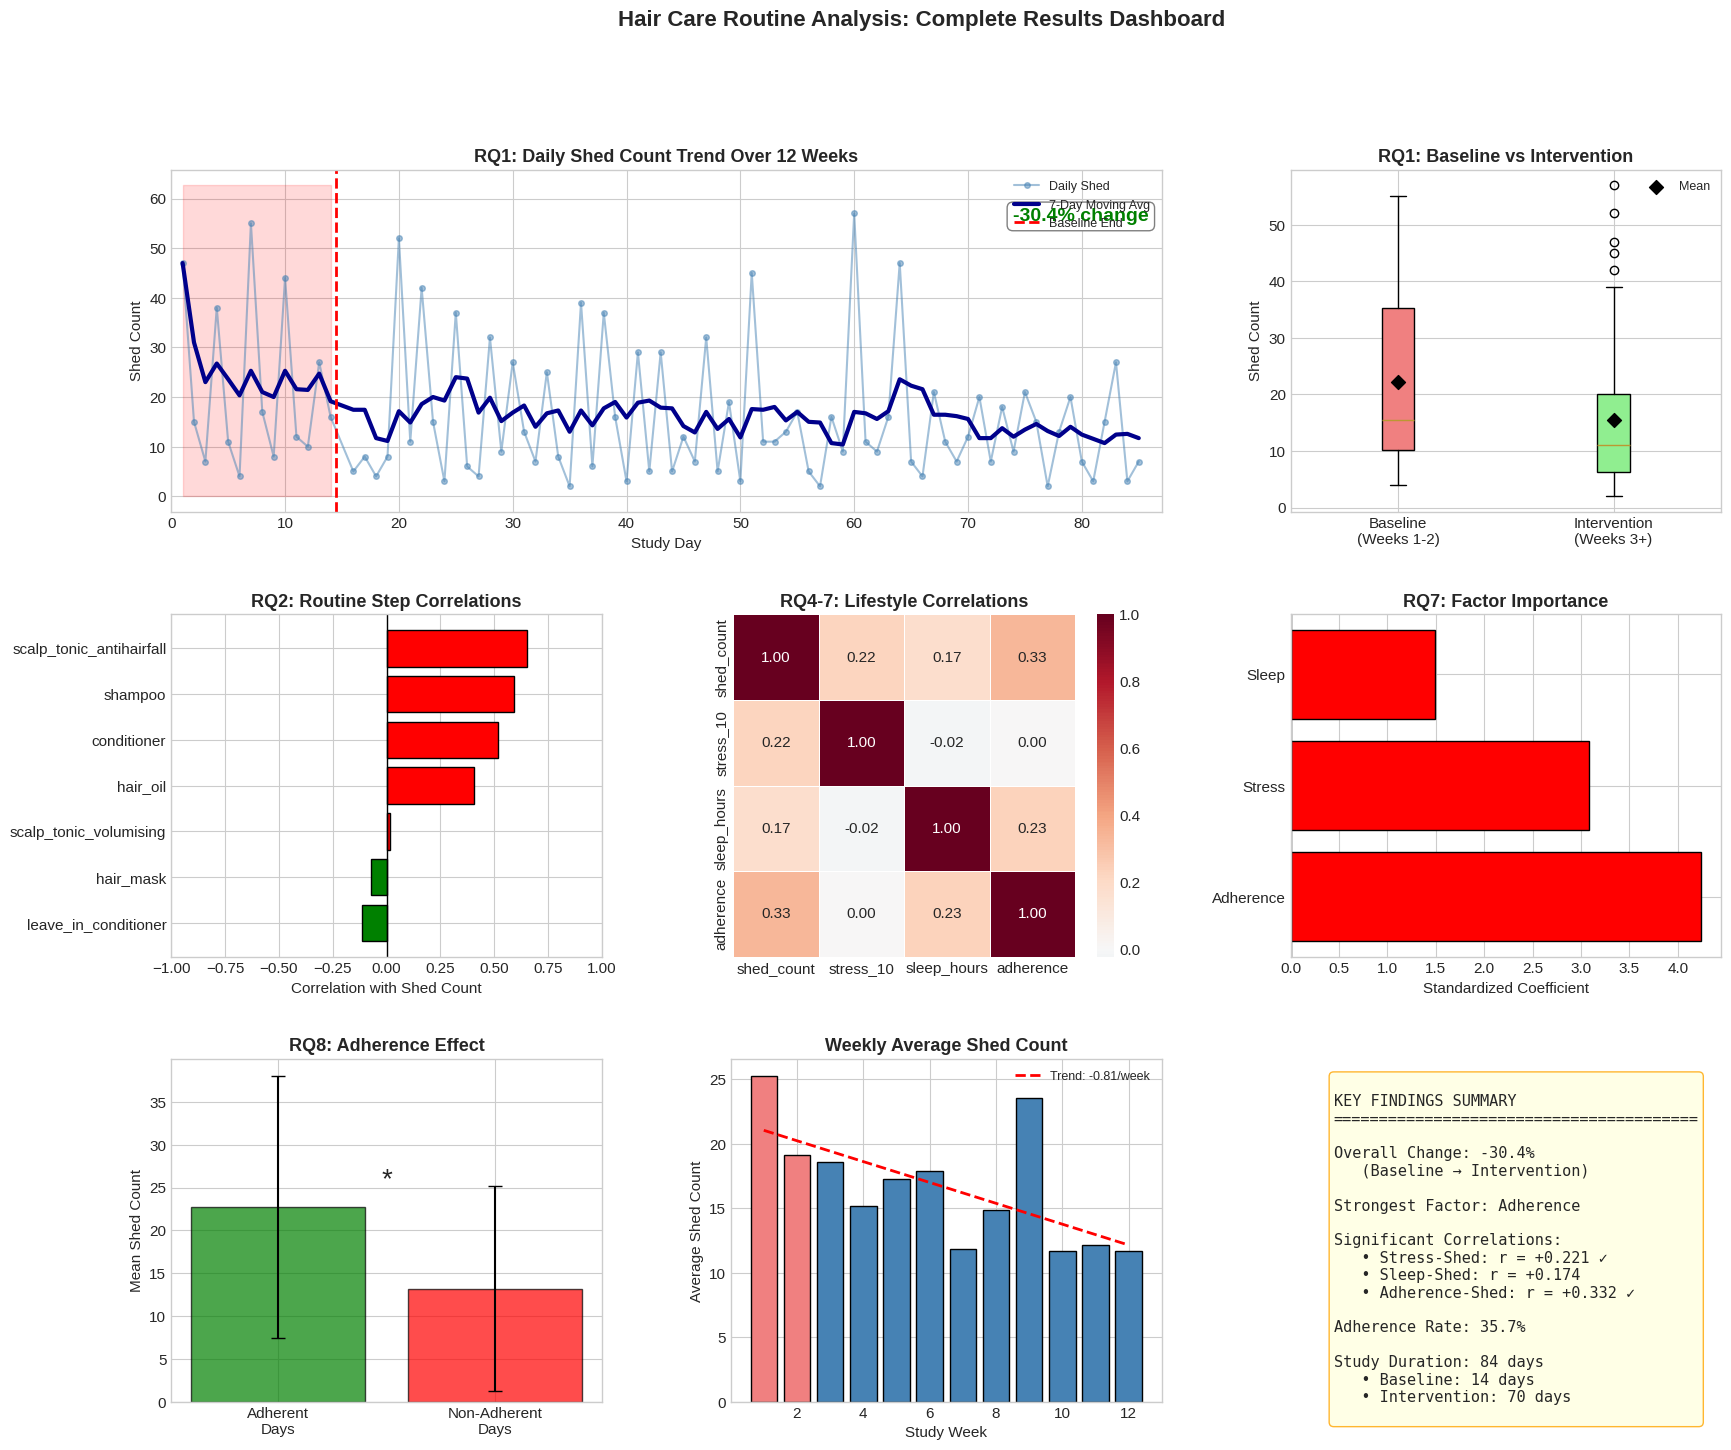


Dashboard saved: complete_results_dashboard.png


In [ ]:
# PART 8: KEY FINDINGS DASHBOARD

fig = plt.figure(figsize=(20, 16))

# Create grid for subplots
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Overall Trend (RQ1)
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(df['study_day_calc'], df['shed_count'], 'o-', alpha=0.5, markersize=4, color='steelblue', label='Daily Shed')
ax1.plot(df['study_day_calc'], df['shed_7day_avg'], '-', linewidth=3, color='darkblue', label='7-Day Moving Avg')
ax1.axvline(x=14.5, color='red', linestyle='--', linewidth=2, label='Baseline End')
ax1.fill_between([1, 14], [0, 0], [df['shed_count'].max()*1.1]*2, alpha=0.15, color='red')
ax1.set_xlabel('Study Day', fontsize=11)
ax1.set_ylabel('Shed Count', fontsize=11)
ax1.set_title('RQ1: Daily Shed Count Trend Over 12 Weeks', fontsize=13, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.set_xlim(0, df['study_day_calc'].max() + 2)

# Add annotation for % change
ax1.annotate(f'{pct_change:+.1f}% change', xy=(0.85, 0.85), xycoords='axes fraction',
             fontsize=14, fontweight='bold', color='green' if pct_change < 0 else 'red',
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

# Plot 2: Phase Comparison Box Plot (RQ1)
ax2 = fig.add_subplot(gs[0, 2])
box_data = [baseline_shed, intervention_shed]
bp = ax2.boxplot(box_data, labels=['Baseline\n(Weeks 1-2)', 'Intervention\n(Weeks 3+)'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
ax2.set_ylabel('Shed Count', fontsize=11)
ax2.set_title('RQ1: Baseline vs Intervention', fontsize=13, fontweight='bold')

# Add means
means = [baseline_shed.mean(), intervention_shed.mean()]
ax2.scatter([1, 2], means, color='black', marker='D', s=50, zorder=5, label='Mean')
ax2.legend(fontsize=9)

# Plot 3: Routine Steps Correlation (RQ2)
ax3 = fig.add_subplot(gs[1, 0])
if len(corr_df) > 0:
    colors = ['green' if x < 0 else 'red' for x in corr_df['correlation']]
    bars = ax3.barh(corr_df.index, corr_df['correlation'], color=colors, edgecolor='black')
    ax3.axvline(x=0, color='black', linewidth=1)
    ax3.set_xlabel('Correlation with Shed Count', fontsize=11)
    ax3.set_title('RQ2: Routine Step Correlations', fontsize=13, fontweight='bold')
    ax3.set_xlim(-1, 1)

# Plot 4: Lifestyle Factors Heatmap (RQ4-7)
ax4 = fig.add_subplot(gs[1, 1])
lifestyle_cols = ['shed_count', 'stress_10', 'sleep_hours', 'adherence']
corr_matrix = df[lifestyle_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=ax4,
            fmt='.2f', square=True, linewidths=0.5)
ax4.set_title('RQ4-7: Lifestyle Correlations', fontsize=13, fontweight='bold')

# Plot 5: Factor Importance (RQ7)
ax5 = fig.add_subplot(gs[1, 2])
if 'coef_importance' in dir():
    colors = ['green' if x < 0 else 'red' for x in coef_importance['Std_Coefficient']]
    ax5.barh(coef_importance['Factor'], coef_importance['Std_Coefficient'],
             color=colors, edgecolor='black')
    ax5.axvline(x=0, color='black', linewidth=1)
    ax5.set_xlabel('Standardized Coefficient', fontsize=11)
    ax5.set_title('RQ7: Factor Importance', fontsize=13, fontweight='bold')

# Plot 6: Adherence Effect (RQ8)
ax6 = fig.add_subplot(gs[2, 0])
adherence_means = [adherent_shed.mean(), non_adherent_shed.mean()]
adherence_stds = [adherent_shed.std(), non_adherent_shed.std()]
x_pos = [0, 1]
colors = ['green', 'red']
ax6.bar(x_pos, adherence_means, yerr=adherence_stds, capsize=5, color=colors,
        edgecolor='black', alpha=0.7)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['Adherent\nDays', 'Non-Adherent\nDays'])
ax6.set_ylabel('Mean Shed Count', fontsize=11)
ax6.set_title('RQ8: Adherence Effect', fontsize=13, fontweight='bold')

# Add significance annotation
if adh_p < 0.05:
    ax6.annotate('*', xy=(0.5, max(adherence_means)*1.1), fontsize=20, ha='center')

# Plot 7: Weekly Trends (RQ10)
ax7 = fig.add_subplot(gs[2, 1])
weekly_shed_plot = df.groupby('study_week')['shed_count'].mean()
ax7.bar(weekly_shed_plot.index, weekly_shed_plot.values,
        color=['lightcoral']*2 + ['steelblue']*(len(weekly_shed_plot)-2),
        edgecolor='black')

# Add trend line
z = np.polyfit(weekly_shed_plot.index, weekly_shed_plot.values, 1)
p_trend = np.poly1d(z)
ax7.plot(weekly_shed_plot.index, p_trend(weekly_shed_plot.index), 'r--',
         linewidth=2, label=f'Trend: {z[0]:+.2f}/week')
ax7.set_xlabel('Study Week', fontsize=11)
ax7.set_ylabel('Average Shed Count', fontsize=11)
ax7.set_title('Weekly Average Shed Count', fontsize=13, fontweight='bold')
ax7.legend(fontsize=9)

# Plot 8: Key Metrics Summary
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')

# Create text summary
summary_text = f"""
KEY FINDINGS SUMMARY
{'='*40}

Overall Change: {pct_change:+.1f}%
   (Baseline → Intervention)

Strongest Factor: {strongest}

Significant Correlations:
   • Stress-Shed: r = {pearson_r:+.3f} {'✓' if pearson_p < 0.05 else ''}
   • Sleep-Shed: r = {same_r:+.3f} {'✓' if same_p < 0.05 else ''}
   • Adherence-Shed: r = {adh_r:+.3f} {'✓' if adh_p < 0.05 else ''}

Adherence Rate: {df['adherence'].mean()*100:.1f}%

Study Duration: {len(df)} days
   • Baseline: 14 days
   • Intervention: {len(df) - 14} days
"""

ax8.text(0.1, 0.95, summary_text, transform=ax8.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', alpha=0.8))

# Main title
fig.suptitle('Hair Care Routine Analysis: Complete Results Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('complete_results_dashboard.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nDashboard saved: complete_results_dashboard.png")

In [ ]:
# PART 9: EXPORT ALL RESULTS

print("EXPORTING ALL RESULTS")
print("-" * 70)

# 1. Export cleaned daily data
df.to_csv('cleaned_daily_data.csv', index=False)
print("✅ Cleaned daily data → cleaned_daily_data.csv")

# 2. Export weekly summary
weekly_df.to_csv('weekly_summary.csv', index=False)
print("✅ Weekly summary → weekly_summary.csv")

# 3. Export routine step correlations
if len(corr_df) > 0:
    corr_df.to_csv('routine_step_correlations.csv')
    print("✅ Routine correlations → routine_step_correlations.csv")

# 4. Export research questions summary
summary_df.to_csv('research_questions_summary.csv', index=False)
print("✅ RQ Summary → research_questions_summary.csv")

# 5. Create comprehensive report
report = f"""
================================================================================
HAIR CARE ROUTINE ANALYSIS - COMPREHENSIVE REPORT
A Data-Driven Evaluation of a 3-Month Hair-Care Routine for Reducing Hair Loss
================================================================================

STUDY OVERVIEW
--------------
• Study Duration: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}
• Total Days Tracked: {len(df)}
• Baseline Period: 14 days (Weeks 1-2)
• Intervention Period: {len(df) - 14} days (Weeks 3+)
• Overall Adherence Rate: {df['adherence'].mean()*100:.1f}%

================================================================================
RESEARCH QUESTION RESULTS
================================================================================

RQ1: OVERALL EFFECTIVENESS
--------------------------
Question: Does average daily shed count significantly decrease from baseline to intervention end?

Results:
• Baseline Mean: {baseline_shed.mean():.2f} hairs/day (SD = {baseline_shed.std():.2f})
• Intervention Mean: {intervention_shed.mean():.2f} hairs/day (SD = {intervention_shed.std():.2f})
• Change: {pct_change:+.1f}%
• Statistical Test: {test_name}
• p-value: {p_one_tailed:.4f}
• Effect Size (Cohen's d): {cohens_d:.3f}
• Conclusion: {'Significant reduction detected' if p_one_tailed < 0.05 else 'No significant reduction detected'}

--------------------------------------------------------------------------------

RQ2: ROUTINE STEPS CORRELATION
------------------------------
Question: Which routine steps correlate with reduced shedding?

Top Steps (Negative correlation = reduces shedding):
{corr_df[['correlation', 'p_value', 'mean_with_step', 'mean_without_step']].to_string()}

--------------------------------------------------------------------------------

RQ3: OPTIMAL ROUTINE COMBINATION
--------------------------------
Question: Is there an optimal combination of routine steps for minimizing shedding?

Regression Model R²: {model.rsquared:.4f}
Best Routine Profile: {optimal_name if 'optimal_name' in dir() else 'See detailed analysis'}

--------------------------------------------------------------------------------

RQ4: STRESS CORRELATION
-----------------------
Question: Is there a significant correlation between stress levels and shed count?

• Pearson r: {pearson_r:.4f} (p = {pearson_p:.4f})
• Spearman ρ: {spearman_r:.4f} (p = {spearman_p:.4f})
• Interpretation: {interpret_correlation(pearson_r)} correlation
• Conclusion: {'Significant' if pearson_p < 0.05 else 'Not significant'}

--------------------------------------------------------------------------------

RQ5: SLEEP → NEXT-DAY SHEDDING
------------------------------
Question: Does sleep duration affect next-day shedding?

• Same-day correlation: r = {same_r:.4f} (p = {same_p:.4f})
• Lagged correlation (sleep → next day shed): r = {lag_r:.4f} (p = {lag_p:.4f})
• Conclusion: {'Delayed effect detected' if abs(lag_r) > abs(same_r) else 'Immediate effect detected'}

--------------------------------------------------------------------------------

RQ6: COMBINED STRESS + SLEEP PREDICTION
---------------------------------------
Question: Do stress and sleep together predict shed count better than individually?

Model Comparison:
• Stress only R²: {model1.rsquared:.4f}
• Sleep only R²: {model2.rsquared:.4f}
• Combined R²: {model3.rsquared:.4f}
• R² Improvement: {improvement:+.2f}%
• Best Model: {best_model_name}

--------------------------------------------------------------------------------

RQ7: STRONGEST FACTOR IDENTIFICATION
------------------------------------
Question: Which factor has the strongest influence on shedding?

Standardized Coefficients (absolute value = importance):
{coef_importance[['Factor', 'Std_Coefficient', 'p-value']].to_string(index=False)}

🏆 Strongest Factor: {strongest}

--------------------------------------------------------------------------------

RQ8: ADHERENCE CORRELATION
--------------------------
Question: Does higher routine adherence correlate with lower shed counts?

• Point-biserial r: {adh_r:.4f} (p = {adh_p:.4f})
• Adherent days mean: {adherent_shed.mean():.2f}
• Non-adherent days mean: {non_adherent_shed.mean():.2f}
• Conclusion: {'Significant relationship' if adh_p < 0.05 else 'No significant relationship'}

--------------------------------------------------------------------------------

RQ9: NON-ADHERENCE → NEXT-DAY EFFECT
------------------------------------
Question: Does breaking routine lead to increased shedding in following days?

• After adherent day: {after_adherent.mean():.2f} hairs
• After non-adherent day: {after_non_adherent.mean():.2f} hairs
• Difference: {after_non_adherent.mean() - after_adherent.mean():+.2f} hairs

--------------------------------------------------------------------------------

RQ10: DENSITY SCORE VS SHED COUNT
---------------------------------
Question: Is there a relationship between density score improvement and shed count reduction?

{'• Correlation: r = ' + f'{density_shed_r:.4f}' + ' (p = ' + f'{density_shed_p:.4f}' + ')' if len(weekly_analysis) >= 3 else '• Insufficient data for analysis'}
{'• Density Trend: ' + f'{density_trend[0]:+.2f}' + ' points/week' if len(weekly_analysis) >= 3 else ''}
{'• Shed Trend: ' + f'{shed_trend[0]:+.2f}' + ' hairs/week' if len(weekly_analysis) >= 3 else ''}

================================================================================
STUDY LIMITATIONS
================================================================================
1. Single-subject study (n=1) - results may not generalize
2. Baseline period lacks scalp density and hair length measurements
3. Wash day vs non-wash day shed counts are not directly comparable
4. Product variations throughout study period
5. Relatively short intervention period ({len(df) - 14} days)

================================================================================
CONCLUSIONS
================================================================================
{f'✓ The routine showed a {abs(pct_change):.1f}% {"reduction" if pct_change < 0 else "increase"} in average daily shed count.' if True else ''}
{f'✓ {strongest} was identified as the strongest predictor of shed count.' if 'strongest' in dir() else ''}
{f'✓ Adherence {"significantly" if adh_p < 0.05 else "did not significantly"} correlate with shed count.' if True else ''}

================================================================================
Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================================
"""

# Save report
with open('comprehensive_report.txt', 'w') as f:
    f.write(report)
print("✅ Comprehensive report → comprehensive_report.txt")

# 6. Download all files (for Google Colab)
from google.colab import files

print("\nDownloading all output files...")

files_to_download = [
    'cleaned_daily_data.csv',
    'weekly_summary.csv',
    'routine_step_correlations.csv',
    'research_questions_summary.csv',
    'comprehensive_report.txt',
    'RQ1_baseline_vs_intervention.png',
    'RQ2_routine_step_correlations.png',
    'RQ3_optimal_routine.png',
    'RQ4-7_lifestyle_factors.png',
    'RQ8-9_adherence_effects.png',
    'RQ10_density_vs_shedding.png',
    'complete_results_dashboard.png'
]

for file in files_to_download:
    try:
        files.download(file)
        print(f"   ✓ {file}")
    except:
        print(f"   ✗ {file} (not found)")

print("\nANALYSIS COMPLETE!")

EXPORTING ALL RESULTS
----------------------------------------------------------------------
✅ Cleaned daily data → cleaned_daily_data.csv
✅ Weekly summary → weekly_summary.csv
✅ Routine correlations → routine_step_correlations.csv
✅ RQ Summary → research_questions_summary.csv
✅ Comprehensive report → comprehensive_report.txt



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✓ cleaned_daily_data.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✓ RQ10_density_vs_shedding.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✓ complete_results_dashboard.png

ANALYSIS COMPLETE!
